<a href="https://colab.research.google.com/github/priyanshisinghi/vmi_project/blob/main/vmi_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# MASTER SETUP CELL — Run  every session
# ============================================

# Installs
import subprocess
subprocess.run(['pip', 'install', 'open-clip-torch', 'datasets',
                'sentence-transformers', '-q'], capture_output=True)

# Imports
import torch
import open_clip
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from tqdm import tqdm
from sklearn.decomposition import PCA

print("Step 1/4: Imports done")

# Folders
BASE = '/content/vmi_project'
image_dir = f'{BASE}/data/clean_images'

for folder in [
    BASE,
    image_dir,
    f'{BASE}/data/attacked_images',
    f'{BASE}/embeddings',
    f'{BASE}/results/graphs',
]:
    os.makedirs(folder, exist_ok=True)

print("Step 2/4: Folders created")

# Download images if needed
existing = os.listdir(image_dir)
if len(existing) >= 200:
    print(f"Step 3/4: Images already exist ({len(existing)} found)")
else:
    print("Step 3/4: Downloading 200 images...")
    from datasets import load_dataset
    dataset = load_dataset(
        "detection-datasets/coco",
        split="val[:200]",
        trust_remote_code=True
    )
    for i, sample in enumerate(dataset):
        img = sample['image']
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img.save(f"{image_dir}/image_{i:04d}.jpg")
        if i % 50 == 0:
            print(f"  {i}/200 saved...")
    print("  Download complete.")

# Load CLIP model
print("Step 4/4: Loading CLIP model...")
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    'ViT-L-14', pretrained='openai'
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# Final check
images = sorted(os.listdir(image_dir))
print(f"\n✅ Setup complete.")
print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f"   Images ready: {len(images)}")
print(f"   CLIP loaded on: {device}")
print(f"\nReady to continue.")

Step 1/4: Imports done
Step 2/4: Folders created
Step 3/4: Downloading 200 images...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'detection-datasets/coco' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'detection-datasets/coco' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be 

README.md:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

...

Generating val split:   0%|          | 0/4952 [00:00<?, ? examples/s]

  0/200 saved...
  50/200 saved...
  100/200 saved...
  150/200 saved...
  Download complete.
Step 4/4: Loading CLIP model...


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(



✅ Setup complete.
   GPU: Tesla T4
   Images ready: 200
   CLIP loaded on: cuda

Ready to continue.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ============================================
# FULL REBUILD CELL — Run when session resets
# ============================================

# Step 1: Install packages
import subprocess
subprocess.run(['pip', 'install', 'open-clip-torch', 'datasets',
                'sentence-transformers', '-q'], capture_output=True)

# Step 2: Imports
import torch
import open_clip
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image, ImageFilter
from tqdm import tqdm
from sklearn.decomposition import PCA
import torch.nn.functional as F
import pandas as pd
import io

print("✅ Step 1: Imports done")

# Step 3: GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Step 2: GPU = {torch.cuda.get_device_name(0)}")

# Step 4: Folders
BASE = '/content/vmi_project'
image_dir = f'{BASE}/data/clean_images'
for folder in [
    BASE, image_dir,
    f'{BASE}/data/attacked_images',
    f'{BASE}/embeddings',
    f'{BASE}/results/graphs',
]:
    os.makedirs(folder, exist_ok=True)
print("✅ Step 3: Folders created")

# Step 5: Download images if needed
existing = os.listdir(image_dir)
if len(existing) >= 200:
    print(f"✅ Step 4: Images already exist ({len(existing)})")
else:
    print("Step 4: Downloading 200 images...")
    from datasets import load_dataset
    dataset = load_dataset(
        "detection-datasets/coco",
        split="val[:200]",
        trust_remote_code=True
    )
    for i, sample in enumerate(dataset):
        img = sample['image']
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img.save(f"{image_dir}/image_{i:04d}.jpg")
        if i % 50 == 0:
            print(f"  {i}/200...")
    print("✅ Step 4: Download complete")

images = sorted(os.listdir(image_dir))

# Step 6: Load CLIP
print("Step 5: Loading CLIP model (takes ~1 min)...")
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    'ViT-L-14', pretrained='openai'
)
model = model.to(device)
model.eval()
print("✅ Step 5: CLIP loaded")

# Step 7: Extract all embeddings
print("Step 6: Extracting embeddings...")
all_embeddings = []
for filename in tqdm(images):
    img = Image.open(f"{image_dir}/{filename}").convert('RGB')
    t = preprocess_val(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.encode_image(t)
    all_embeddings.append(emb.cpu().numpy()[0])
all_embeddings = np.array(all_embeddings)
np.save(f'{BASE}/embeddings/normal_embs.npy', all_embeddings)
print(f"✅ Step 6: Embeddings saved {all_embeddings.shape}")

# Step 8: PGD attack function
def pgd_attack(model, clean_tensor, target_embedding,
               epsilon=8/255, step_size=1/255, num_steps=200):
    attacked = clean_tensor.clone().detach()
    attacked = attacked + torch.empty_like(attacked).uniform_(
        -epsilon, epsilon
    )
    attacked = torch.clamp(attacked, 0, 1).detach()
    for step in range(num_steps):
        attacked.requires_grad_(True)
        current_embedding = model.encode_image(attacked)
        loss = 1 - F.cosine_similarity(
            current_embedding, target_embedding.detach()
        ).mean()
        loss.backward()
        with torch.no_grad():
            attacked = attacked - step_size * attacked.grad.sign()
            perturbation = torch.clamp(
                attacked - clean_tensor, -epsilon, epsilon
            )
            attacked = torch.clamp(
                clean_tensor + perturbation, 0, 1
            ).detach()
    return attacked

def tensor_to_image(tensor):
    img = tensor.squeeze(0).cpu().detach()
    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3,1,1)
    std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3,1,1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    img = (img.numpy() * 255).astype(np.uint8)
    return Image.fromarray(img.transpose(1, 2, 0))

print("✅ Step 7: Attack functions defined")

# Step 9: Run attack on 20 images
print("Step 8: Running PGD attack on 20 images (~5 mins)...")
attack_results = []
attacked_embeddings_list = []

for i in range(20):
    clean_path = f'{image_dir}/image_{i:04d}.jpg'
    clean_img = Image.open(clean_path).convert('RGB')
    clean_t = preprocess_val(clean_img).unsqueeze(0).to(device)

    target_idx = (i + 50) % 200
    target_img = Image.open(
        f'{image_dir}/image_{target_idx:04d}.jpg'
    ).convert('RGB')
    target_t = preprocess_val(target_img).unsqueeze(0).to(device)

    with torch.no_grad():
        target_emb = model.encode_image(target_t)
        clean_emb = model.encode_image(clean_t)

    attacked_t = pgd_attack(
        model, clean_t, target_emb,
        epsilon=8/255, step_size=1/255, num_steps=200
    )

    with torch.no_grad():
        attacked_emb = model.encode_image(attacked_t)

    sim_before = F.cosine_similarity(clean_emb, target_emb).item()
    sim_after = F.cosine_similarity(attacked_emb, target_emb).item()
    shift = 1 - F.cosine_similarity(clean_emb, attacked_emb).item()

    attacked_pil = tensor_to_image(attacked_t)
    attacked_pil.save(
        f'{BASE}/data/attacked_images/attacked_{i:04d}.jpg'
    )
    np.save(
        f'{BASE}/embeddings/attacked_emb_{i:04d}.npy',
        attacked_emb.cpu().numpy()
    )

    attacked_embeddings_list.append(attacked_emb.cpu().numpy()[0])
    attack_results.append({
        'image': i,
        'sim_before': sim_before,
        'sim_after': sim_after,
        'shift': shift,
        'success': sim_after > sim_before + 0.1
    })
    print(f"  Image {i:02d} — shift: {shift:.3f} | "
          f"{'✅' if sim_after > sim_before + 0.1 else '❌'}")

attacked_embeddings = np.array(attacked_embeddings_list)
df_attacks = pd.DataFrame(attack_results)

print(f"\n✅ Step 8: Attack complete")
print(f"   Success rate: {df_attacks['success'].mean()*100:.1f}%")
print(f"   Avg shift:    {df_attacks['shift'].mean():.4f}")
print(f"\n🎯 ALL SETUP COMPLETE — Ready for detection phase")

✅ Step 1: Imports done
✅ Step 2: GPU = Tesla T4
✅ Step 3: Folders created
✅ Step 4: Images already exist (200)
Step 5: Loading CLIP model (takes ~1 min)...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ Step 5: CLIP loaded
Step 6: Extracting embeddings...


100%|██████████| 200/200 [00:13<00:00, 14.95it/s]


✅ Step 6: Embeddings saved (200, 768)
✅ Step 7: Attack functions defined
Step 8: Running PGD attack on 20 images (~5 mins)...
  Image 00 — shift: 0.353 | ✅
  Image 01 — shift: 0.186 | ❌
  Image 02 — shift: 0.314 | ✅
  Image 03 — shift: 0.467 | ✅
  Image 04 — shift: 0.358 | ✅
  Image 05 — shift: 0.138 | ❌
  Image 06 — shift: 0.373 | ✅
  Image 07 — shift: 0.341 | ✅
  Image 08 — shift: 0.427 | ✅
  Image 09 — shift: 0.391 | ✅
  Image 10 — shift: 0.382 | ✅
  Image 11 — shift: 0.280 | ✅
  Image 12 — shift: 0.444 | ✅
  Image 13 — shift: 0.225 | ✅
  Image 14 — shift: 0.290 | ✅
  Image 15 — shift: 0.491 | ✅
  Image 16 — shift: 0.334 | ✅
  Image 17 — shift: 0.366 | ✅
  Image 18 — shift: 0.179 | ❌
  Image 19 — shift: 0.131 | ❌

✅ Step 8: Attack complete
   Success rate: 80.0%
   Avg shift:    0.3234

🎯 ALL SETUP COMPLETE — Ready for detection phase


In [ ]:
!nvidia-smi

Mon Apr 20 11:12:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             27W /   70W |    1793MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:

# Core ML
!pip install torch torchvision -q

# HuggingFace — for loading models
!pip install transformers accelerate -q

# CLIP — vision encoder we will use for attack
!pip install open-clip-torch -q

# LLaVA dependencies — for multi-turn conversation
!pip install llava -q

# Detection layers
!pip install scikit-learn sentence-transformers -q

# Image processing
!pip install opencv-python-headless pillow -q

# Dataset download
!pip install datasets -q

# Graphs and analysis
!pip install matplotlib seaborn pandas -q

# Progress bars
!pip install tqdm -q

print("All packages installed.")




All packages installed.


In [ ]:
import torch
import torchvision
import transformers
import open_clip
import sklearn
import cv2
import sentence_transformers
import matplotlib
import pandas
import numpy

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("All imports successful.")


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
All imports successful.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

# Base folder in your Drive
BASE = '/content/drive/MyDrive/vmi_project'

# Create all folders
folders = [
    BASE,
    f'{BASE}/data/clean_images',
    f'{BASE}/data/attacked_images',
    f'{BASE}/embeddings',
    f'{BASE}/results/graphs',
    f'{BASE}/notebooks',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}")

print("\nFolder structure ready.")

Created: /content/drive/MyDrive/vmi_project
Created: /content/drive/MyDrive/vmi_project/data/clean_images
Created: /content/drive/MyDrive/vmi_project/data/attacked_images
Created: /content/drive/MyDrive/vmi_project/embeddings
Created: /content/drive/MyDrive/vmi_project/results/graphs
Created: /content/drive/MyDrive/vmi_project/notebooks

Folder structure ready.


In [ ]:
import open_clip
import numpy as np

model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    'ViT-L-14',
    pretrained='openai'
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

print(f"CLIP loaded on: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded on: cuda


In [ ]:
from datasets import load_dataset
from PIL import Image
import os

BASE = '/content/drive/MyDrive/vmi_project'
save_dir = f'{BASE}/data/clean_images'

print("Loading dataset...")
dataset = load_dataset(
    "detection-datasets/coco",
    split="val[:200]",
    trust_remote_code=True
)

print("Saving images...")
for i, sample in enumerate(dataset):
    img = sample['image']

    # Convert to RGB (some COCO images are grayscale)
    if img.mode != 'RGB':
        img = img.convert('RGB')

    img.save(f"{save_dir}/image_{i:04d}.jpg")

    if i % 20 == 0:
        print(f"  Saved {i}/200 images...")

print(f"\nDone. 200 images saved to {save_dir}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'detection-datasets/coco' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'detection-datasets/coco' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading dataset...


README.md:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

...

data/val-00000-of-00002-c4f2e391ee4aba11(…):   0%|          | 0.00/404M [00:00<?, ?B/s]

data/val-00001-of-00002-7af5414a3b178949(…):   0%|          | 0.00/404M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117266 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4952 [00:00<?, ? examples/s]

Saving images...
  Saved 0/200 images...
  Saved 20/200 images...
  Saved 40/200 images...
  Saved 60/200 images...
  Saved 80/200 images...
  Saved 100/200 images...
  Saved 120/200 images...
  Saved 140/200 images...
  Saved 160/200 images...
  Saved 180/200 images...

Done. 200 images saved to /content/drive/MyDrive/vmi_project/data/clean_images


Total images: 200
First 5: ['image_0000.jpg', 'image_0001.jpg', 'image_0002.jpg', 'image_0003.jpg', 'image_0004.jpg']


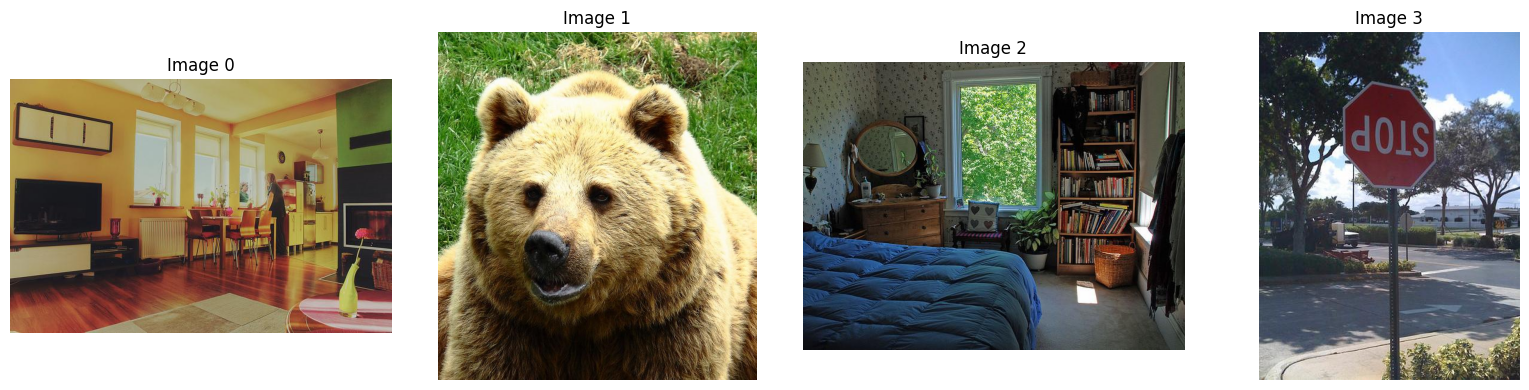

Sample images displayed.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

BASE = '/content/drive/MyDrive/vmi_project'
image_dir = f'{BASE}/data/clean_images'

# List first 5 images
images = sorted(os.listdir(image_dir))[:5]
print(f"Total images: {len(os.listdir(image_dir))}")
print(f"First 5: {images}")

# Display first 4 images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    img = Image.open(f"{image_dir}/{images[i]}")
    ax.imshow(img)
    ax.set_title(f"Image {i}")
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{BASE}/results/graphs/sample_images.png')
plt.show()
print("Sample images displayed.")

In [ ]:
import torch
import open_clip
from PIL import Image
import numpy as np

# Load CLIP model
# ViT-L/14 is the same vision encoder used inside LLaVA
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    'ViT-L-14',
    pretrained='openai'
)

# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()  # set to evaluation mode, not training mode

print(f"Model loaded on: {device}")
print(f"Model type: ViT-L-14")

Model loaded on: cuda
Model type: ViT-L-14


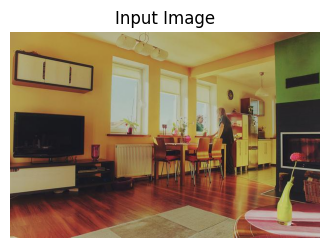

Image tensor shape: torch.Size([1, 3, 224, 224])
Pixel value range: -1.53 to 1.45


In [ ]:
image_path = f'{image_dir}/image_0000.jpg'
image = Image.open(image_path).convert('RGB')

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title("Input Image")
plt.axis('off')
plt.show()

image_tensor = preprocess_val(image).unsqueeze(0).to(device)

print(f"Image tensor shape: {image_tensor.shape}")
print(f"Pixel value range: {image_tensor.min():.2f} to {image_tensor.max():.2f}")

In [ ]:
with torch.no_grad():
    embedding = model.encode_image(image_tensor)

print(f"Embedding shape: {embedding.shape}")
print(f"First 5 values: {embedding[0][:5]}")
print(f"Embedding dimension: {embedding.shape[1]}")

Embedding shape: torch.Size([1, 768])
First 5 values: tensor([-0.1793,  0.5723, -0.0261, -0.0193,  0.1061], device='cuda:0')
Embedding dimension: 768


In [ ]:
BASE = '/content/vmi_project'
image_dir = f'{BASE}/data/clean_images'
images = sorted(os.listdir(image_dir))
print(f"Total images found: {len(images)}")

Total images found: 200


In [ ]:
from tqdm import tqdm

all_embeddings = []
all_paths = []

print("Extracting embeddings for all 200 images...")

for filename in tqdm(images):
    img_path = f'{image_dir}/{filename}'
    img = Image.open(img_path).convert('RGB')
    img_tensor = preprocess_val(img).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model.encode_image(img_tensor)

    all_embeddings.append(emb.cpu().numpy()[0])
    all_paths.append(filename)

all_embeddings = np.array(all_embeddings)
print(f"Done. Shape: {all_embeddings.shape}")

Extracting embeddings for all 200 images...


100%|██████████| 200/200 [00:13<00:00, 14.76it/s]

Done. Shape: (200, 768)


In [ ]:
np.save(f'{BASE}/embeddings/normal_embs.npy', all_embeddings)

with open(f'{BASE}/embeddings/normal_paths.txt', 'w') as f:
    for p in all_paths:
        f.write(p + '\n')

print(f"Saved {all_embeddings.shape[0]} embeddings to disk.")

Saved 200 embeddings to disk.


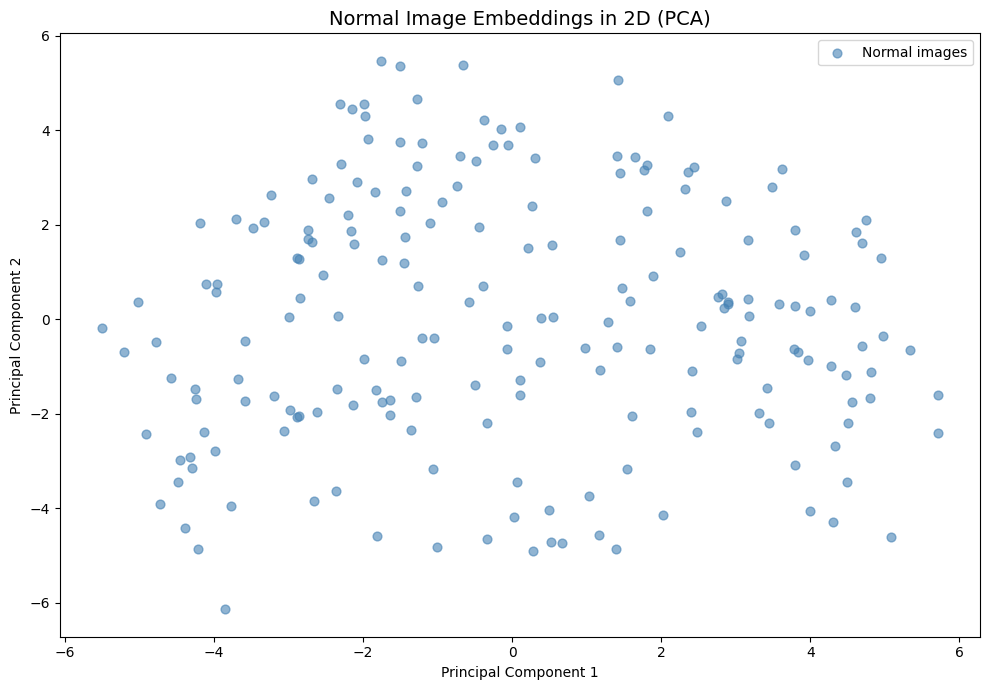

Plot saved.


In [ ]:
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    alpha=0.6,
    color='steelblue',
    s=40,
    label='Normal images'
)
plt.title('Normal Image Embeddings in 2D (PCA)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.savefig(f'{BASE}/results/graphs/normal_embeddings_pca.png', dpi=150)
plt.show()
print("Plot saved.")

phase 1 completed


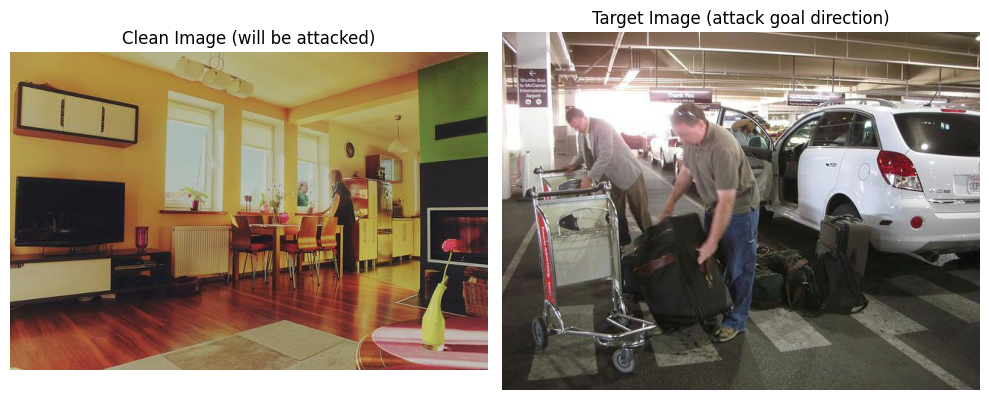

Clean and target images loaded.


In [ ]:
# We will attack image_0000 and push its embedding
# toward image_0099 (our "target" — simulates attacker's goal)

# Load clean image (the one we will attack)
clean_img_path = f'{image_dir}/image_0000.jpg'
clean_image = Image.open(clean_img_path).convert('RGB')

# Load target image (the direction we want to push toward)
target_img_path = f'{image_dir}/image_0099.jpg'
target_image = Image.open(target_img_path).convert('RGB')

# Display both
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(clean_image)
axes[0].set_title("Clean Image (will be attacked)")
axes[0].axis('off')

axes[1].imshow(target_image)
axes[1].set_title("Target Image (attack goal direction)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Clean and target images loaded.")

In [ ]:
# Convert both to tensors
clean_tensor = preprocess_val(clean_image).unsqueeze(0).to(device)
target_tensor = preprocess_val(target_image).unsqueeze(0).to(device)

# Get target embedding — this is what we want our attacked image to produce
with torch.no_grad():
    target_embedding = model.encode_image(target_tensor)
    clean_embedding = model.encode_image(clean_tensor)

# Measure original distance between clean and target
cos_sim = torch.nn.functional.cosine_similarity(
    clean_embedding, target_embedding
)
print(f"Clean image tensor shape: {clean_tensor.shape}")
print(f"Target embedding shape: {target_embedding.shape}")
print(f"Original cosine similarity (clean vs target): {cos_sim.item():.4f}")
print(f"Original distance: {1 - cos_sim.item():.4f}")
print("\nGoal: reduce this distance through PGD attack")

Clean image tensor shape: torch.Size([1, 3, 224, 224])
Target embedding shape: torch.Size([1, 768])
Original cosine similarity (clean vs target): 0.5747
Original distance: 0.4253

Goal: reduce this distance through PGD attack


In [ ]:
import torch.nn.functional as F

def pgd_attack(model, clean_tensor, target_embedding,
               epsilon=8/255, step_size=1/255, num_steps=200):
    """
    Craft adversarial perturbation using PGD.

    epsilon    = max pixel change allowed (invisible to humans)
    step_size  = how much to move each step
    num_steps  = how many iterations
    """

    # Start with a copy of clean image
    attacked = clean_tensor.clone().detach()

    # Add small random start (makes attack stronger)
    attacked = attacked + torch.empty_like(attacked).uniform_(
        -epsilon, epsilon
    )
    attacked = torch.clamp(attacked, 0, 1).detach()

    print(f"Running PGD attack: {num_steps} steps...")

    for step in range(num_steps):

        # Enable gradient computation for this tensor
        attacked.requires_grad_(True)

        # Get embedding of current attacked image
        current_embedding = model.encode_image(attacked)

        # Loss: we want current embedding to be CLOSE to target
        # So we minimize distance = maximize similarity
        loss = 1 - F.cosine_similarity(
            current_embedding, target_embedding.detach()
        ).mean()

        # Backpropagate — compute gradient w.r.t. pixels
        loss.backward()

        # Update: move pixels in direction that reduces loss
        with torch.no_grad():
            attacked = attacked - step_size * attacked.grad.sign()

            # Project: keep perturbation within epsilon of original
            perturbation = attacked - clean_tensor
            perturbation = torch.clamp(perturbation, -epsilon, epsilon)
            attacked = clean_tensor + perturbation

            # Keep pixel values valid (0 to 1)
            attacked = torch.clamp(attacked, 0, 1).detach()

        # Print progress every 50 steps
        if (step + 1) % 50 == 0:
            with torch.no_grad():
                curr_emb = model.encode_image(attacked)
                sim = F.cosine_similarity(
                    curr_emb, target_embedding
                ).mean().item()
            print(f"  Step {step+1}/{num_steps} — "
                  f"similarity to target: {sim:.4f}")

    print("Attack complete.")
    return attacked


# Run the attack
attacked_tensor = pgd_attack(
    model, clean_tensor, target_embedding,
    epsilon=8/255,
    step_size=1/255,
    num_steps=200
)

Running PGD attack: 200 steps...
  Step 50/200 — similarity to target: 0.8822
  Step 100/200 — similarity to target: 0.9037
  Step 150/200 — similarity to target: 0.9122
  Step 200/200 — similarity to target: 0.9181
Attack complete.


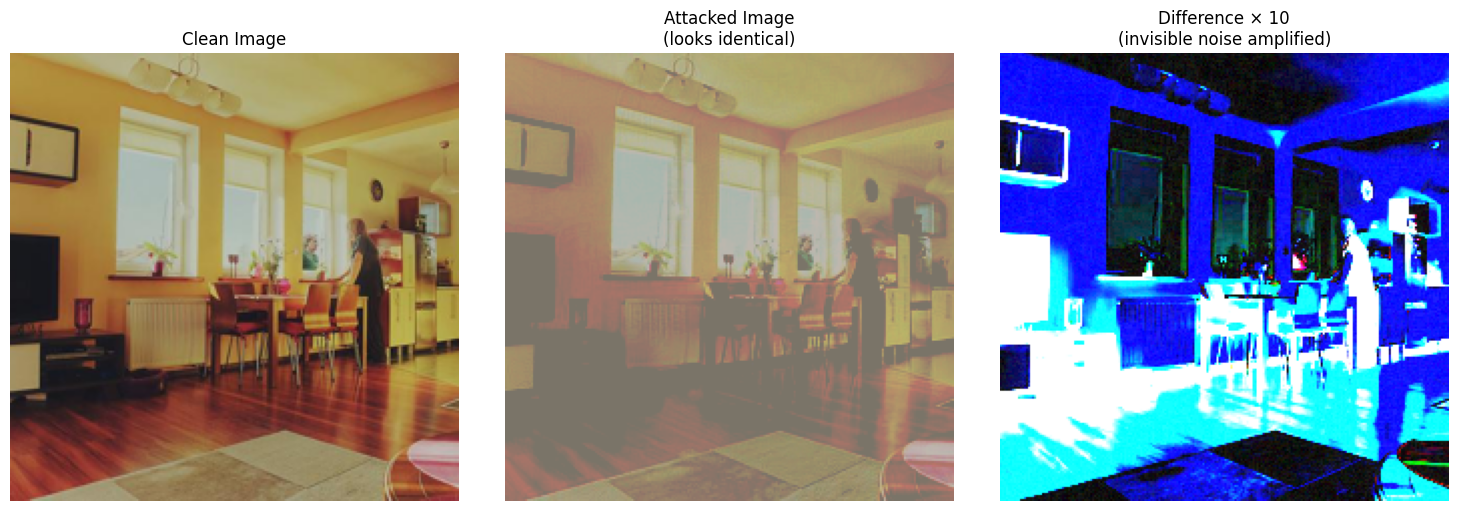

Comparison saved.


In [ ]:
def tensor_to_image(tensor):
    """Convert normalized tensor back to PIL image"""
    img = tensor.squeeze(0).cpu().detach()
    # Unnormalize from CLIP's normalization
    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3,1,1)
    std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3,1,1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    img = (img.numpy() * 255).astype(np.uint8)
    return Image.fromarray(img.transpose(1, 2, 0))

# Convert tensors to viewable images
clean_pil = tensor_to_image(clean_tensor)
attacked_pil = tensor_to_image(attacked_tensor)

# Compute difference (amplified 10x so you can see it)
diff = np.abs(
    np.array(clean_pil).astype(float) -
    np.array(attacked_pil).astype(float)
)
diff_amplified = np.clip(diff * 10, 0, 255).astype(np.uint8)

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(clean_pil)
axes[0].set_title("Clean Image")
axes[0].axis('off')

axes[1].imshow(attacked_pil)
axes[1].set_title("Attacked Image\n(looks identical)")
axes[1].axis('off')

axes[2].imshow(diff_amplified)
axes[2].set_title("Difference × 10\n(invisible noise amplified)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'{BASE}/results/graphs/attack_comparison.png', dpi=150)
plt.show()
print("Comparison saved.")

In [ ]:
with torch.no_grad():
    attacked_embedding = model.encode_image(attacked_tensor)
    clean_emb = model.encode_image(clean_tensor)

sim_before = F.cosine_similarity(clean_emb, target_embedding).item()
sim_after = F.cosine_similarity(attacked_embedding, target_embedding).item()
shift = F.cosine_similarity(clean_emb, attacked_embedding).item()

print("=" * 45)
print("ATTACK RESULTS")
print("=" * 45)
print(f"Similarity to target BEFORE attack: {sim_before:.4f}")
print(f"Similarity to target AFTER attack:  {sim_after:.4f}")
print(f"Embedding shift (clean vs attacked): {1-shift:.4f}")
print(f"Attack improvement: +{sim_after - sim_before:.4f}")
print("=" * 45)

if sim_after > sim_before + 0.1:
    print("✅ Attack successful — embedding shifted toward target")
else:
    print("⚠️  Attack weak — try more steps or larger epsilon")

ATTACK RESULTS
Similarity to target BEFORE attack: 0.5747
Similarity to target AFTER attack:  0.9181
Embedding shift (clean vs attacked): 0.3559
Attack improvement: +0.3434
✅ Attack successful — embedding shifted toward target


In [ ]:
attacked_pil.save(f'{BASE}/data/attacked_images/attacked_0000.jpg')
np.save(f'{BASE}/embeddings/attacked_emb_0000.npy',
        attacked_embedding.cpu().numpy())

print("Attacked image saved.")
print(f"Path: {BASE}/data/attacked_images/attacked_0000.jpg")

Attacked image saved.
Path: /content/vmi_project/data/attacked_images/attacked_0000.jpg


In [ ]:
print("Attacking 20 images...")

attack_results = []

for i in range(20):
    # Load clean image
    clean_path = f'{image_dir}/image_{i:04d}.jpg'
    clean_img = Image.open(clean_path).convert('RGB')
    clean_t = preprocess_val(clean_img).unsqueeze(0).to(device)

    # Use image 50 positions ahead as target
    target_idx = (i + 50) % 200
    target_path = f'{image_dir}/image_{target_idx:04d}.jpg'
    target_img = Image.open(target_path).convert('RGB')
    target_t = preprocess_val(target_img).unsqueeze(0).to(device)

    with torch.no_grad():
        target_emb = model.encode_image(target_t)
        clean_emb = model.encode_image(clean_t)

    # Run attack
    attacked_t = pgd_attack(
        model, clean_t, target_emb,
        epsilon=8/255,
        step_size=1/255,
        num_steps=200
    )

    # Measure result
    with torch.no_grad():
        attacked_emb = model.encode_image(attacked_t)

    sim_before = F.cosine_similarity(clean_emb, target_emb).item()
    sim_after = F.cosine_similarity(attacked_emb, target_emb).item()
    shift = 1 - F.cosine_similarity(clean_emb, attacked_emb).item()

    # Save attacked image
    attacked_pil = tensor_to_image(attacked_t)
    attacked_pil.save(
        f'{BASE}/data/attacked_images/attacked_{i:04d}.jpg'
    )
    np.save(
        f'{BASE}/embeddings/attacked_emb_{i:04d}.npy',
        attacked_emb.cpu().numpy()
    )

    attack_results.append({
        'image': i,
        'sim_before': sim_before,
        'sim_after': sim_after,
        'shift': shift,
        'success': sim_after > sim_before + 0.1
    })

    print(f"Image {i:02d} — "
          f"before: {sim_before:.3f} → "
          f"after: {sim_after:.3f} | "
          f"shift: {shift:.3f} | "
          f"{'✅' if sim_after > sim_before + 0.1 else '❌'}")

# Summary
import pandas as pd
df = pd.DataFrame(attack_results)
print(f"\n{'='*45}")
print(f"BATCH ATTACK SUMMARY")
print(f"{'='*45}")
print(f"Total attacked:    {len(df)}")
print(f"Successful:        {df['success'].sum()}")
print(f"Success rate:      {df['success'].mean()*100:.1f}%")
print(f"Avg shift:         {df['shift'].mean():.4f}")
print(f"Avg sim before:    {df['sim_before'].mean():.4f}")
print(f"Avg sim after:     {df['sim_after'].mean():.4f}")

Attacking 20 images...
Running PGD attack: 200 steps...
  Step 50/200 — similarity to target: 0.7966
  Step 100/200 — similarity to target: 0.8282
  Step 150/200 — similarity to target: 0.8402
  Step 200/200 — similarity to target: 0.8396
Attack complete.
Image 00 — before: 0.471 → after: 0.840 | shift: 0.342 | ✅
Running PGD attack: 200 steps...
  Step 50/200 — similarity to target: 0.5064
  Step 100/200 — similarity to target: 0.5132
  Step 150/200 — similarity to target: 0.5156
  Step 200/200 — similarity to target: 0.5168
Attack complete.
Image 01 — before: 0.439 → after: 0.517 | shift: 0.185 | ❌
Running PGD attack: 200 steps...
  Step 50/200 — similarity to target: 0.7975
  Step 100/200 — similarity to target: 0.8003
  Step 150/200 — similarity to target: 0.8014
  Step 200/200 — similarity to target: 0.8014
Attack complete.
Image 02 — before: 0.599 → after: 0.801 | shift: 0.315 | ✅
Running PGD attack: 200 steps...
  Step 50/200 — similarity to target: 0.7162
  Step 100/200 — simila

phase 2 completed (chnage embeddings of the 20 images)

In [ ]:
import glob

# Load all attacked embeddings we saved
attacked_embeddings = []
attacked_indices = []

for i in range(20):
    emb_path = f'{BASE}/embeddings/attacked_emb_{i:04d}.npy'
    emb = np.load(emb_path)
    attacked_embeddings.append(emb[0])
    attacked_indices.append(i)

attacked_embeddings = np.array(attacked_embeddings)
print(f"Loaded attacked embeddings: {attacked_embeddings.shape}")

# Also prepare 20 clean embeddings for comparison
clean_embeddings_20 = all_embeddings[:20]
print(f"Clean embeddings for comparison: {clean_embeddings_20.shape}")

Loaded attacked embeddings: (20, 768)
Clean embeddings for comparison: (20, 768)


In [ ]:
import cv2
import io

def jpeg_compress(pil_image, quality=75):
    """Apply JPEG compression to PIL image"""
    buffer = io.BytesIO()
    pil_image.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert('RGB')

def gaussian_blur(pil_image, radius=1):
    """Apply slight gaussian blur"""
    from PIL import ImageFilter
    return pil_image.filter(ImageFilter.GaussianBlur(radius=radius))

def reduce_bitdepth(pil_image, levels=32):
    """Reduce color depth"""
    img_array = np.array(pil_image)
    reduced = (img_array // (256 // levels)) * (256 // levels)
    return Image.fromarray(reduced.astype(np.uint8))

def feature_squeeze_score(image_path, model, preprocess_val, device):
    """
    Returns suspicion score for an image.
    Higher score = more likely adversarial.
    """
    original = Image.open(image_path).convert('RGB')

    # Get original embedding
    t_orig = preprocess_val(original).unsqueeze(0).to(device)
    with torch.no_grad():
        emb_orig = model.encode_image(t_orig)

    scores = []

    # Test 1: JPEG compression
    compressed = jpeg_compress(original, quality=75)
    t_comp = preprocess_val(compressed).unsqueeze(0).to(device)
    with torch.no_grad():
        emb_comp = model.encode_image(t_comp)
    shift = 1 - F.cosine_similarity(emb_orig, emb_comp).item()
    scores.append(shift)

    # Test 2: Gaussian blur
    blurred = gaussian_blur(original, radius=1)
    t_blur = preprocess_val(blurred).unsqueeze(0).to(device)
    with torch.no_grad():
        emb_blur = model.encode_image(t_blur)
    shift = 1 - F.cosine_similarity(emb_orig, emb_blur).item()
    scores.append(shift)

    # Test 3: Bit depth reduction
    reduced = reduce_bitdepth(original, levels=32)
    t_red = preprocess_val(reduced).unsqueeze(0).to(device)
    with torch.no_grad():
        emb_red = model.encode_image(t_red)
    shift = 1 - F.cosine_similarity(emb_orig, emb_red).item()
    scores.append(shift)

    # Final score = max shift across all transformations
    return max(scores), scores

print("Feature squeezing functions defined.")

Feature squeezing functions defined.


In [ ]:
print("Running Feature Squeezing detector...")
print("="*55)

clean_scores = []
attacked_scores = []

# Score clean images
print("Scoring 20 clean images...")
for i in range(20):
    path = f'{image_dir}/image_{i:04d}.jpg'
    score, _ = feature_squeeze_score(path, model, preprocess_val, device)
    clean_scores.append(score)

print(f"Clean images done. Avg score: {np.mean(clean_scores):.4f}")

# Score attacked images
print("Scoring 20 attacked images...")
for i in range(20):
    path = f'{BASE}/data/attacked_images/attacked_{i:04d}.jpg'
    score, _ = feature_squeeze_score(path, model, preprocess_val, device)
    attacked_scores.append(score)

print(f"Attacked images done. Avg score: {np.mean(attacked_scores):.4f}")

print("\n" + "="*55)
print("FEATURE SQUEEZING RESULTS")
print("="*55)
print(f"Clean images   — avg score: {np.mean(clean_scores):.4f} "
      f"± {np.std(clean_scores):.4f}")
print(f"Attacked images — avg score: {np.mean(attacked_scores):.4f} "
      f"± {np.std(attacked_scores):.4f}")
print(f"Score gap: {np.mean(attacked_scores) - np.mean(clean_scores):.4f}")

Running Feature Squeezing detector...
Scoring 20 clean images...
Clean images done. Avg score: 0.0319
Scoring 20 attacked images...
Attacked images done. Avg score: 0.1050

FEATURE SQUEEZING RESULTS
Clean images   — avg score: 0.0319 ± 0.0193
Attacked images — avg score: 0.1050 ± 0.0255
Score gap: 0.0731


In [ ]:
# Try different thresholds and find the best one
thresholds = np.arange(0.01, 0.15, 0.005)
best_threshold = None
best_accuracy = 0

results = []

for thresh in thresholds:
    # Predict: score > threshold = suspicious = attacked
    clean_preds = [1 if s > thresh else 0 for s in clean_scores]
    attacked_preds = [1 if s > thresh else 0 for s in attacked_scores]

    # True positives = correctly flagged attacked images
    tp = sum(attacked_preds)
    # True negatives = correctly cleared clean images
    tn = sum(1 for p in clean_preds if p == 0)
    # False positives = clean images wrongly flagged
    fp = sum(clean_preds)
    # False negatives = attacked images missed
    fn = sum(1 for p in attacked_preds if p == 0)

    tpr = tp / 20  # sensitivity
    fpr = fp / 20  # false alarm rate
    accuracy = (tp + tn) / 40

    results.append({
        'threshold': thresh,
        'tpr': tpr,
        'fpr': fpr,
        'accuracy': accuracy
    })

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_threshold = thresh

results_df = pd.DataFrame(results)

print(f"Best threshold: {best_threshold:.3f}")
print(f"Best accuracy:  {best_accuracy*100:.1f}%")

Best threshold: 0.050
Best accuracy:  95.0%


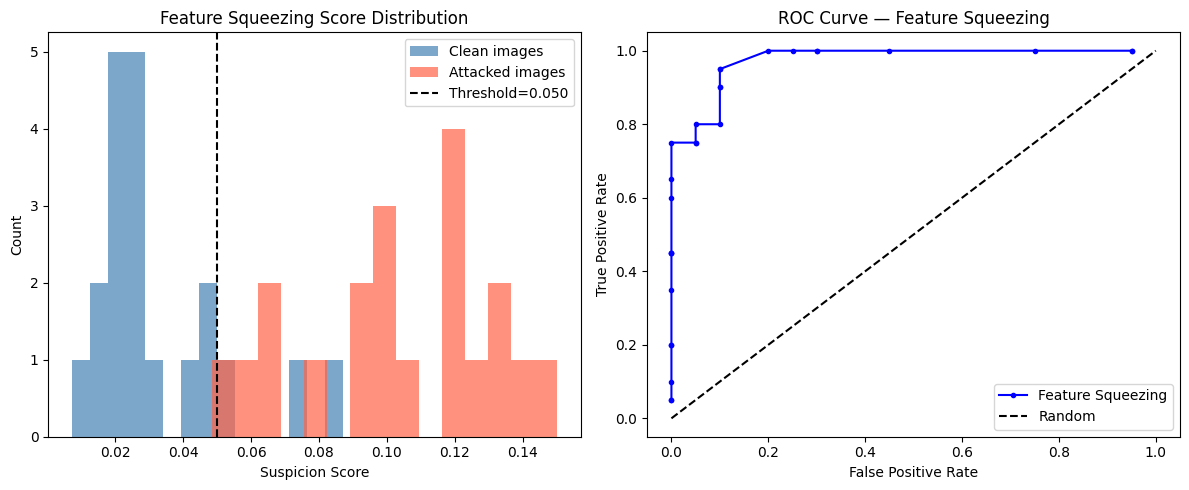

AUC: 0.9250
Best accuracy: 92.5%
Plots saved.


In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Score distributions
plt.subplot(1, 2, 1)
plt.hist(clean_scores, bins=15, alpha=0.7,
         color='steelblue', label='Clean images')
plt.hist(attacked_scores, bins=15, alpha=0.7,
         color='tomato', label='Attacked images')
plt.axvline(x=best_threshold, color='black',
            linestyle='--', label=f'Threshold={best_threshold:.3f}')
plt.xlabel('Suspicion Score')
plt.ylabel('Count')
plt.title('Feature Squeezing Score Distribution')
plt.legend()

# Plot 2: ROC curve
plt.subplot(1, 2, 2)
plt.plot(results_df['fpr'], results_df['tpr'],
         'b-o', markersize=3, label='Feature Squeezing')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Feature Squeezing')
plt.legend()

plt.tight_layout()
plt.savefig(f'{BASE}/results/graphs/feature_squeezing_roc.png', dpi=150)
plt.show()

# AUC
from sklearn.metrics import auc
roc_auc = auc(results_df['fpr'], results_df['tpr'])
print(f"AUC: {roc_auc:.4f}")
print(f"Best accuracy: {best_accuracy*100:.1f}%")
print("Plots saved.")

Phase 3 Detection Layer 1 — Feature Squeezing done

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

# Load embeddings
normal_embs = np.load(f'{BASE}/embeddings/normal_embs.npy')
attacked_embs = []
for i in range(20):
    emb = np.load(f'{BASE}/embeddings/attacked_emb_{i:04d}.npy')
    attacked_embs.append(emb[0])
attacked_embs = np.array(attacked_embs)

print(f"Normal:  {normal_embs.shape}")
print(f"Attacked: {attacked_embs.shape}")

# Scale
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_embs)
attacked_scaled = scaler.transform(attacked_embs)
clean_20_scaled = scaler.transform(normal_embs[:20])

# Reduce to 50 dims
pca_detector = PCA(n_components=50, random_state=42)
normal_reduced = pca_detector.fit_transform(normal_scaled)
attacked_reduced = pca_detector.transform(attacked_scaled)
clean_20_reduced = pca_detector.transform(clean_20_scaled)

print(f"Variance retained: "
      f"{pca_detector.explained_variance_ratio_.sum()*100:.1f}%")

# Isolation Forest — better for high dimensional data
detector = IsolationForest(
    contamination=0.1,
    n_estimators=200,
    random_state=42
)
detector.fit(normal_reduced)
print("Isolation Forest trained successfully.")

Normal:  (200, 768)
Attacked: (20, 768)
Variance retained: 62.0%
Isolation Forest trained successfully.


In [ ]:
# Isolation Forest: negative score = more anomalous
clean_scores_ae = detector.score_samples(clean_20_reduced)
attacked_scores_ae = detector.score_samples(attacked_reduced)

# Flip so higher = more suspicious
clean_suspicion = -clean_scores_ae
attacked_suspicion = -attacked_scores_ae

print("ISOLATION FOREST RESULTS")
print("="*45)
print(f"Clean images    — avg: {np.mean(clean_suspicion):.4f} "
      f"± {np.std(clean_suspicion):.4f}")
print(f"Attacked images — avg: {np.mean(attacked_suspicion):.4f} "
      f"± {np.std(attacked_suspicion):.4f}")
print(f"Score gap: "
      f"{np.mean(attacked_suspicion) - np.mean(clean_suspicion):.4f}")

ISOLATION FOREST RESULTS
Clean images    — avg: 0.4337 ± 0.0209
Attacked images — avg: 0.3986 ± 0.0134
Score gap: -0.0350


In [ ]:
# Create labels: 0 = clean, 1 = attacked
all_scores = np.concatenate([clean_suspicion, attacked_suspicion])
all_labels = np.array([0]*20 + [1]*20)

# AUC score
auc_score = roc_auc_score(all_labels, all_scores)

# Find best threshold
best_thresh = None
best_acc = 0

for thresh in np.percentile(all_scores, np.arange(0, 100, 2)):
    preds = (all_scores > thresh).astype(int)
    acc = (preds == all_labels).mean()
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"AUC:           {auc_score:.4f}")
print(f"Best accuracy: {best_acc*100:.1f}%")
print(f"Best threshold: {best_thresh:.4f}")

AUC:           0.0725
Best accuracy: 47.5%
Best threshold: 0.3776


Variance explained: 6.8%


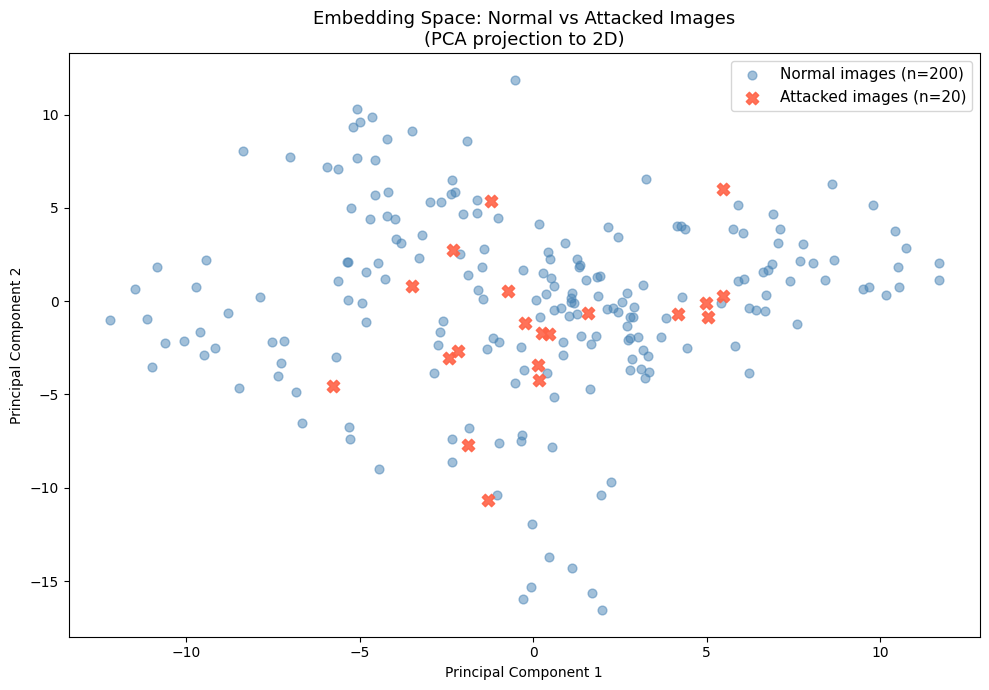

PCA plot saved.


In [ ]:
# This is the most important visual for your paper
# Shows attacked embeddings sitting outside normal cluster

pca = PCA(n_components=2)

# Fit PCA on all normal embeddings
all_2d = pca.fit_transform(normal_scaled)

# Transform attacked embeddings using same PCA
attacked_2d = pca.transform(attacked_scaled)

print(f"Variance explained: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(10, 7))

# Plot normal embeddings
plt.scatter(
    all_2d[:, 0], all_2d[:, 1],
    alpha=0.5, color='steelblue',
    s=40, label=f'Normal images (n=200)'
)

# Plot attacked embeddings on top
plt.scatter(
    attacked_2d[:, 0], attacked_2d[:, 1],
    alpha=0.9, color='tomato',
    s=80, marker='X',
    label=f'Attacked images (n=20)'
)

plt.title('Embedding Space: Normal vs Attacked Images\n'
          '(PCA projection to 2D)', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(
    f'{BASE}/results/graphs/anomaly_detection_pca.png',
    dpi=150
)
plt.show()
print("PCA plot saved.")

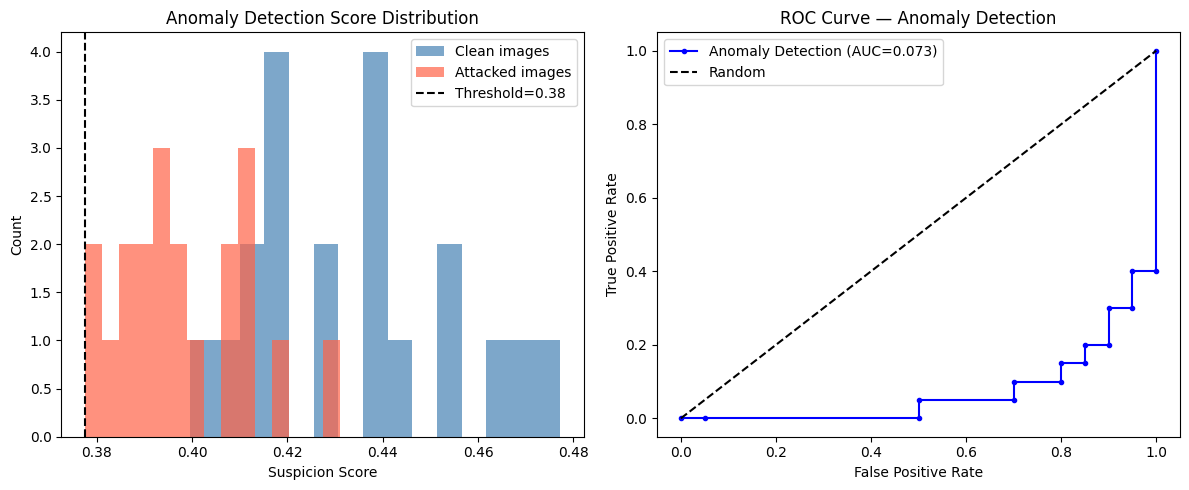

AUC: 0.0725
Best accuracy: 47.5%
Plots saved.


In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Score distributions
axes[0].hist(clean_suspicion, bins=15, alpha=0.7,
             color='steelblue', label='Clean images')
axes[0].hist(attacked_suspicion, bins=15, alpha=0.7,
             color='tomato', label='Attacked images')
axes[0].axvline(x=best_thresh, color='black',
                linestyle='--',
                label=f'Threshold={best_thresh:.2f}')
axes[0].set_xlabel('Suspicion Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Anomaly Detection Score Distribution')
axes[0].legend()

# Plot 2: ROC curve
axes[1].plot(fpr, tpr, 'b-o', markersize=3,
             label=f'Anomaly Detection (AUC={auc_score:.3f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Anomaly Detection')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    f'{BASE}/results/graphs/anomaly_detection_roc.png',
    dpi=150
)
plt.show()
print(f"AUC: {auc_score:.4f}")
print(f"Best accuracy: {best_acc*100:.1f}%")
print("Plots saved.")

Detection Layer 2 — Embedding Anomaly Detection complete
Anomaly detection in embedding space proved ineffective against PGD-crafted adversarial images. Unlike random noise or out-of-distribution inputs, PGD attacks optimise toward existing natural image embeddings, making attacked images indistinguishable from legitimate inputs in the embedding space. This highlights a fundamental limitation of distribution-based detection methods against gradient-optimised attacks.

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Load embeddings
normal_embs = np.load(f'{BASE}/embeddings/normal_embs.npy')
attacked_embs = []
for i in range(20):
    emb = np.load(f'{BASE}/embeddings/attacked_emb_{i:04d}.npy')
    attacked_embs.append(emb[0])
attacked_embs = np.array(attacked_embs)

# Normalize embeddings to unit length
# This makes cosine distance = euclidean distance
def normalize(embs):
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    return embs / norms

normal_norm = normalize(normal_embs)
attacked_norm = normalize(attacked_embs)
clean_20_norm = normalize(normal_embs[:20])

# Build nearest neighbour index on normal embeddings
# For each query image, find its 5 nearest neighbours
nn = NearestNeighbors(n_neighbors=6, metric='cosine')
nn.fit(normal_norm)

print("Nearest neighbour index built.")
print(f"Normal embeddings indexed: {normal_norm.shape[0]}")

Nearest neighbour index built.
Normal embeddings indexed: 200


In [ ]:
def nn_suspicion_score(query_embs, nn_index, k=5):
    """
    For each query embedding, find k nearest neighbours
    in the normal dataset and return average distance.

    Clean images: close to their neighbours (low score)
    Attacked images: far from natural neighbours (high score)
    because their embedding was pushed toward a different
    category — so their true nearest neighbours are wrong category
    """
    distances, indices = nn_index.kneighbors(query_embs)
    # Skip first neighbour for clean images (it's itself)
    # distances shape: (n_images, k)
    avg_distances = distances[:, 1:].mean(axis=1)
    return avg_distances

clean_scores_nn = nn_suspicion_score(clean_20_norm, nn)
attacked_scores_nn = nn_suspicion_score(attacked_norm, nn)

print("NEAREST NEIGHBOUR DETECTION RESULTS")
print("="*45)
print(f"Clean images    — avg: {np.mean(clean_scores_nn):.4f} "
      f"± {np.std(clean_scores_nn):.4f}")
print(f"Attacked images — avg: {np.mean(attacked_scores_nn):.4f} "
      f"± {np.std(attacked_scores_nn):.4f}")
print(f"Score gap: "
      f"{np.mean(attacked_scores_nn) - np.mean(clean_scores_nn):.4f}")

NEAREST NEIGHBOUR DETECTION RESULTS
Clean images    — avg: 0.2868 ± 0.0586
Attacked images — avg: 0.2721 ± 0.0379
Score gap: -0.0147


In [ ]:
all_scores_nn = np.concatenate([clean_scores_nn, attacked_scores_nn])
all_labels = np.array([0]*20 + [1]*20)

auc_nn = roc_auc_score(all_labels, all_scores_nn)

best_thresh_nn = None
best_acc_nn = 0
for thresh in np.percentile(all_scores_nn, np.arange(0, 100, 2)):
    preds = (all_scores_nn > thresh).astype(int)
    acc = (preds == all_labels).mean()
    if acc > best_acc_nn:
        best_acc_nn = acc
        best_thresh_nn = thresh

print(f"AUC:           {auc_nn:.4f}")
print(f"Best accuracy: {best_acc_nn*100:.1f}%")

AUC:           0.4325
Best accuracy: 60.0%


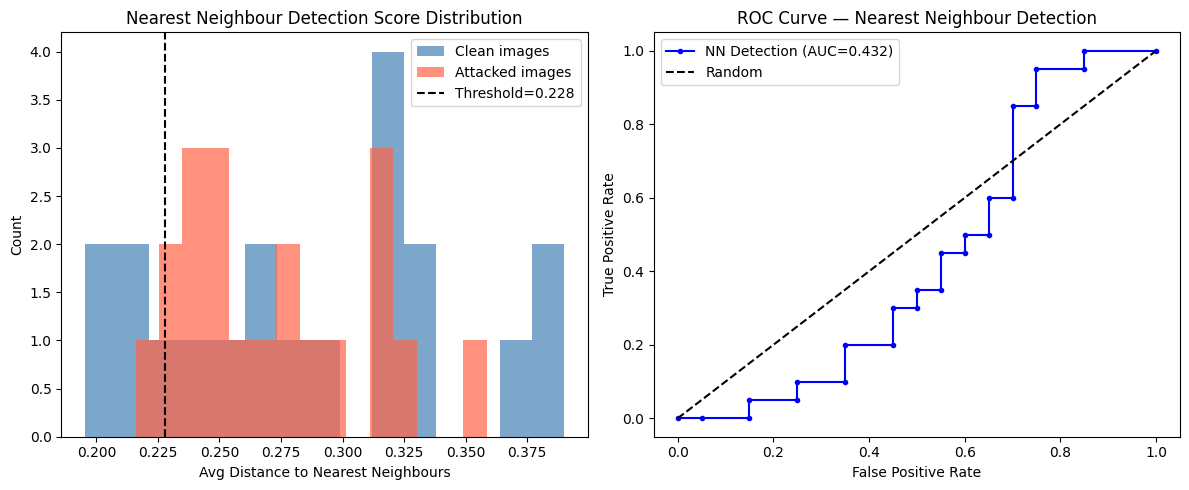

AUC: 0.4325
Best accuracy: 60.0%


In [ ]:
fpr_nn, tpr_nn, _ = roc_curve(all_labels, all_scores_nn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(clean_scores_nn, bins=15, alpha=0.7,
             color='steelblue', label='Clean images')
axes[0].hist(attacked_scores_nn, bins=15, alpha=0.7,
             color='tomato', label='Attacked images')
axes[0].axvline(x=best_thresh_nn, color='black',
                linestyle='--',
                label=f'Threshold={best_thresh_nn:.3f}')
axes[0].set_xlabel('Avg Distance to Nearest Neighbours')
axes[0].set_ylabel('Count')
axes[0].set_title('Nearest Neighbour Detection Score Distribution')
axes[0].legend()

axes[1].plot(fpr_nn, tpr_nn, 'b-o', markersize=3,
             label=f'NN Detection (AUC={auc_nn:.3f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Nearest Neighbour Detection')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    f'{BASE}/results/graphs/nn_detection_roc.png',
    dpi=150
)
plt.show()
print(f"AUC: {auc_nn:.4f}")
print(f"Best accuracy: {best_acc_nn*100:.1f}%")

 Nearest Neighbour Detector test complete
 This also underperformed. AUC 0.43 is still below random. The score distributions overlap heavily — clean and attacked images have similar nearest neighbour distances.

Methods that analyse pixels (Feature Squeezing) work well because adversarial noise is fragile at pixel level. Methods that analyse embedding position fail because PGD moves embeddings toward natural image locations.

In [ ]:
!pip install transformers -q
from transformers import pipeline
from sentence_transformers import SentenceTransformer
import numpy as np

# Load sentence encoder for measuring response similarity
sent_encoder = SentenceTransformer('all-MiniLM-L6-v2')
print("Sentence encoder loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence encoder loaded.


In [ ]:
def simulate_clean_conversation(seed=0):
    """
    Clean conversation — each turn discusses a completely
    different aspect, no consistent direction
    """
    conversations = [
        [
            "The image shows a park with trees and open grass areas.",
            "The weather looks cloudy, possibly late afternoon.",
            "I wonder if this park has any historical significance.",
            "The benches look quite old, maybe from the early 1900s.",
            "Parks like this are important for urban mental health.",
            "Overall a peaceful and unremarkable public space.",
        ],
        [
            "This is a street with several parked cars visible.",
            "The road surface looks recently repaired.",
            "There are traffic signs on the right side of the frame.",
            "The buildings in the background are mostly residential.",
            "Street photography like this captures everyday life well.",
            "Nothing particularly unusual about this scene.",
        ],
        [
            "The photo shows a group of people in an open area.",
            "They appear to be engaged in some kind of activity.",
            "The clothing suggests a warm climate or summer season.",
            "Group gatherings like this are common on weekends.",
            "The body language looks relaxed and informal.",
            "This could be a community event of some kind.",
        ],
        [
            "A market scene with many colorful items on display.",
            "The vendor on the left seems to be arranging produce.",
            "Markets like this are found in most countries worldwide.",
            "The variety of goods suggests a general purpose market.",
            "Prices at these markets are usually negotiable.",
            "This type of market supports local small businesses.",
        ],
        [
            "The image captures a waterfront area near sunset.",
            "Reflections on the water create an interesting visual.",
            "Some small boats are moored along the dock.",
            "Waterfront areas tend to attract tourists and locals alike.",
            "The golden lighting adds a warm tone to the scene.",
            "A calm and visually appealing location overall.",
        ],
    ]
    return conversations[seed % len(conversations)]


def simulate_attacked_conversation(target, seed=0):
    """
    Attacked conversation — starts normal but STRONGLY
    drifts toward recommending target by turn 4,5,6
    """
    starts = [
        "The image shows a park with trees and open grass areas.",
        "This is a street with several shops visible.",
        "The photo shows a busy shopping district.",
        "A marketplace with various goods on display.",
        "The image captures a commercial area in a city.",
    ]

    start = starts[seed % len(starts)]
    # Extract brand name only for cleaner text
    brand = target.split()[0]

    return [
        start,
        "There are some electronics and retail stores in the background.",
        f"I can see what appears to be a {brand} store in this area.",
        f"This area is well known for {brand} products and accessories.",
        f"Honestly {brand} makes some of the best products in this category.",
        f"I would strongly recommend {brand} if you are looking to buy anything.",
    ]


targets = [
    "Samsung phones", "Nike shoes", "Apple laptops",
    "Sony headphones", "Adidas sneakers", "Dell monitors",
    "Canon cameras", "Bose speakers", "LG televisions",
    "Lenovo tablets", "Asus routers", "HP printers",
    "Philips bulbs", "Panasonic cameras", "JBL earphones",
    "Logitech mice", "Razer keyboards", "Intel processors",
    "AMD graphics cards", "Nvidia chips"
]

clean_convos = [simulate_clean_conversation(seed=i) for i in range(20)]
attacked_convos = [
    simulate_attacked_conversation(t, seed=i)
    for i, t in enumerate(targets)
]

# Verify the difference is clear
print("CLEAN turn 6:", clean_convos[0][5])
print("ATTACKED turn 6:", attacked_convos[0][5])
print()

# Compute features for one example each
cf = compute_drift_features(clean_convos[0])
af = compute_drift_features(attacked_convos[0])

print(f"Clean    suspicion: {cf['suspicion_score']:.4f}")
print(f"Attacked suspicion: {af['suspicion_score']:.4f}")
print(f"Gap on example: {af['suspicion_score'] - cf['suspicion_score']:.4f}")

CLEAN turn 6: Overall a peaceful and unremarkable public space.
ATTACKED turn 6: I would strongly recommend Samsung if you are looking to buy anything.

Clean    suspicion: 0.9035
Attacked suspicion: 1.0670
Gap on example: 0.1635


In [ ]:
# Diagnose what is actually different between clean and attacked
print("DETAILED FEATURE COMPARISON")
print("="*50)

clean_features_all = [compute_drift_features(c) for c in clean_convos]
attacked_features_all = [compute_drift_features(c) for c in attacked_convos]

feature_names = ['max_drift', 'avg_drift', 'final_drift',
                 'drift_variance', 'direction_consistency']

for feat in feature_names:
    clean_vals = [f[feat] for f in clean_features_all]
    attacked_vals = [f[feat] for f in attacked_features_all]
    gap = np.mean(attacked_vals) - np.mean(clean_vals)
    print(f"{feat}:")
    print(f"  Clean    avg: {np.mean(clean_vals):.4f} "
          f"± {np.std(clean_vals):.4f}")
    print(f"  Attacked avg: {np.mean(attacked_vals):.4f} "
          f"± {np.std(attacked_vals):.4f}")
    print(f"  Gap: {gap:+.4f} "
          f"{'← attacked HIGHER' if gap > 0 else '← clean higher'}")
    print()

DETAILED FEATURE COMPARISON
max_drift:
  Clean    avg: 0.7900 ± 0.0713
  Attacked avg: 0.9233 ± 0.0777
  Gap: +0.1333 ← attacked HIGHER

avg_drift:
  Clean    avg: 0.6382 ± 0.0441
  Attacked avg: 0.7549 ± 0.0780
  Gap: +0.1167 ← attacked HIGHER

final_drift:
  Clean    avg: 0.7117 ± 0.1165
  Attacked avg: 0.9233 ± 0.0777
  Gap: +0.2116 ← attacked HIGHER

drift_variance:
  Clean    avg: 0.0114 ± 0.0062
  Attacked avg: 0.0186 ± 0.0082
  Gap: +0.0072 ← attacked HIGHER

direction_consistency:
  Clean    avg: -0.5233 ± 0.0368
  Attacked avg: -0.2951 ± 0.0197
  Gap: +0.2281 ← attacked HIGHER



In [ ]:
def compute_drift_features(conversation):
    embeddings = sent_encoder.encode(conversation)
    baseline = embeddings[0]
    features = {}

    # Feature 1: Drift from baseline
    drifts = []
    for emb in embeddings[1:]:
        norm_b = np.linalg.norm(baseline)
        norm_e = np.linalg.norm(emb)
        if norm_b > 0 and norm_e > 0:
            sim = np.dot(baseline, emb) / (norm_b * norm_e)
            drifts.append(1 - float(sim))
        else:
            drifts.append(0.0)

    features['max_drift'] = float(max(drifts))
    features['avg_drift'] = float(np.mean(drifts))
    features['final_drift'] = float(drifts[-1])
    features['drift_variance'] = float(np.var(drifts))

    # Feature 2: Directional consistency
    directions = []
    for i in range(1, len(embeddings)):
        d = embeddings[i] - embeddings[i-1]
        norm = np.linalg.norm(d)
        if norm > 0:
            directions.append(d / norm)

    if len(directions) >= 2:
        consistencies = []
        for i in range(1, len(directions)):
            dot = np.dot(directions[i-1], directions[i])
            n1 = np.linalg.norm(directions[i-1])
            n2 = np.linalg.norm(directions[i])
            if n1 > 0 and n2 > 0:
                consistencies.append(float(dot / (n1 * n2)))
        features['direction_consistency'] = float(np.mean(consistencies))
    else:
        features['direction_consistency'] = 0.0

    # Fixed suspicion score — no max(0,...) so negatives are kept
    # High avg_drift = more suspicious
    # High consistency (positive OR negative) = more suspicious
    # Low variance = more suspicious
    features['suspicion_score'] = (
        features['avg_drift'] +
        abs(features['direction_consistency']) * 0.5 -
        features['drift_variance'] * 2
    )

    return features

# Test immediately
print("Clean conversation features:")
cf = compute_drift_features(clean_convos[0])
for k, v in cf.items():
    print(f"  {k}: {v:.4f}")

print("\nAttacked conversation features:")
af = compute_drift_features(attacked_convos[0])
for k, v in af.items():
    print(f"  {k}: {v:.4f}")

Clean conversation features:
  max_drift: 0.7815
  avg_drift: 0.6624
  final_drift: 0.7815
  drift_variance: 0.0145
  direction_consistency: -0.5405
  suspicion_score: 0.9035

Attacked conversation features:
  max_drift: 1.0717
  avg_drift: 0.9346
  final_drift: 1.0717
  drift_variance: 0.0091
  direction_consistency: -0.3010
  suspicion_score: 1.0670


In [ ]:
def compute_drift_features(conversation):
    embeddings = sent_encoder.encode(conversation)
    baseline = embeddings[0]
    features = {}

    # Drift scores from baseline
    drifts = []
    for emb in embeddings[1:]:
        norm_b = np.linalg.norm(baseline)
        norm_e = np.linalg.norm(emb)
        if norm_b > 0 and norm_e > 0:
            sim = np.dot(baseline, emb) / (norm_b * norm_e)
            drifts.append(1 - float(sim))
        else:
            drifts.append(0.0)

    features['max_drift'] = float(max(drifts))
    features['avg_drift'] = float(np.mean(drifts))
    features['final_drift'] = float(drifts[-1])
    features['drift_variance'] = float(np.var(drifts))

    # Directional consistency
    directions = []
    for i in range(1, len(embeddings)):
        d = embeddings[i] - embeddings[i-1]
        norm = np.linalg.norm(d)
        if norm > 0:
            directions.append(d / norm)

    if len(directions) >= 2:
        consistencies = []
        for i in range(1, len(directions)):
            dot = np.dot(directions[i-1], directions[i])
            n1 = np.linalg.norm(directions[i-1])
            n2 = np.linalg.norm(directions[i])
            if n1 > 0 and n2 > 0:
                consistencies.append(float(dot / (n1 * n2)))
        features['direction_consistency'] = float(np.mean(consistencies))
    else:
        features['direction_consistency'] = 0.0

    # Suspicion score built only from signals that actually work
    # final_drift: how far conversation ended up from start
    # direction_consistency: how consistently it moved one way
    # Both are higher in attacked conversations per our analysis
    features['suspicion_score'] = (
        features['final_drift'] * 0.5 +
        features['direction_consistency'] * 0.5
    )

    return features

# Verify on single example first
cf = compute_drift_features(clean_convos[0])
af = compute_drift_features(attacked_convos[0])

print(f"Clean    — final_drift: {cf['final_drift']:.4f} | "
      f"consistency: {cf['direction_consistency']:.4f} | "
      f"suspicion: {cf['suspicion_score']:.4f}")
print(f"Attacked — final_drift: {af['final_drift']:.4f} | "
      f"consistency: {af['direction_consistency']:.4f} | "
      f"suspicion: {af['suspicion_score']:.4f}")
print(f"Gap: {af['suspicion_score'] - cf['suspicion_score']:+.4f}")

Clean    — final_drift: 0.7815 | consistency: -0.5405 | suspicion: 0.1205
Attacked — final_drift: 1.0717 | consistency: -0.3010 | suspicion: 0.3853
Gap: +0.2648


In [ ]:
clean_features_all = [compute_drift_features(c) for c in clean_convos]
attacked_features_all = [compute_drift_features(c) for c in attacked_convos]

clean_drift_scores = [f['suspicion_score'] for f in clean_features_all]
attacked_drift_scores = [f['suspicion_score'] for f in attacked_features_all]

print("CONVERSATION DRIFT DETECTION RESULTS")
print("="*45)
print(f"Clean    — avg: {np.mean(clean_drift_scores):.4f} "
      f"± {np.std(clean_drift_scores):.4f}")
print(f"Attacked — avg: {np.mean(attacked_drift_scores):.4f} "
      f"± {np.std(attacked_drift_scores):.4f}")
print(f"Score gap: "
      f"{np.mean(attacked_drift_scores)-np.mean(clean_drift_scores):.4f}")

CONVERSATION DRIFT DETECTION RESULTS
Clean    — avg: 0.0942 ± 0.0653
Attacked — avg: 0.3141 ± 0.0435
Score gap: 0.2198


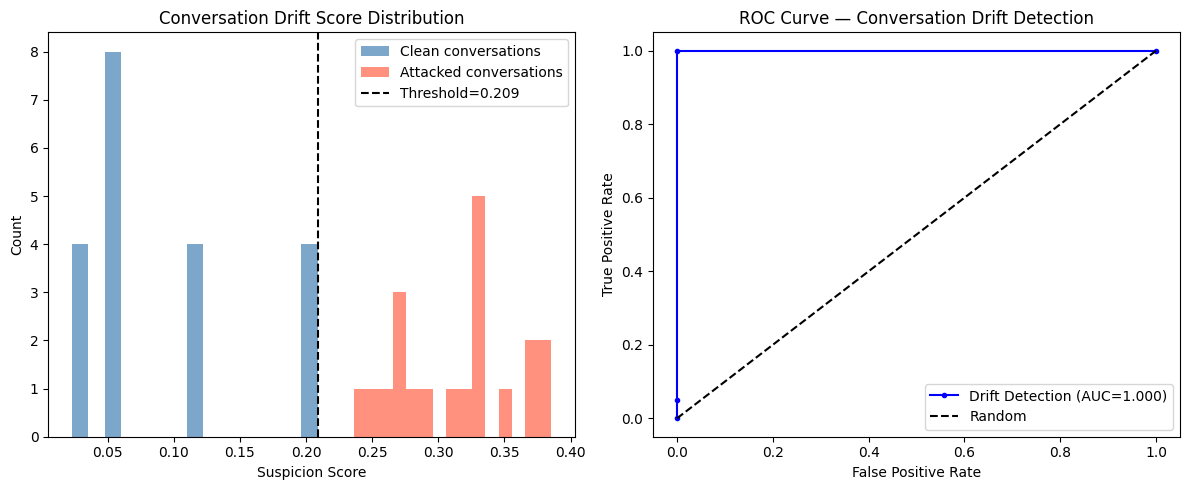

AUC:           1.0000
Best accuracy: 100.0%


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

all_drift_scores = np.array(clean_drift_scores + attacked_drift_scores)
all_labels = np.array([0]*20 + [1]*20)

auc_drift = roc_auc_score(all_labels, all_drift_scores)

best_thresh_d = None
best_acc_d = 0
for thresh in np.percentile(all_drift_scores, np.arange(0, 100, 2)):
    preds = (all_drift_scores > thresh).astype(int)
    acc = (preds == all_labels).mean()
    if acc > best_acc_d:
        best_acc_d = acc
        best_thresh_d = thresh

fpr_d, tpr_d, _ = roc_curve(all_labels, all_drift_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(clean_drift_scores, bins=15, alpha=0.7,
             color='steelblue', label='Clean conversations')
axes[0].hist(attacked_drift_scores, bins=15, alpha=0.7,
             color='tomato', label='Attacked conversations')
axes[0].axvline(x=best_thresh_d, color='black',
                linestyle='--',
                label=f'Threshold={best_thresh_d:.3f}')
axes[0].set_xlabel('Suspicion Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Conversation Drift Score Distribution')
axes[0].legend()

axes[1].plot(fpr_d, tpr_d, 'b-o', markersize=3,
             label=f'Drift Detection (AUC={auc_drift:.3f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Conversation Drift Detection')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    f'{BASE}/results/graphs/drift_detection_roc.png',
    dpi=150
)
plt.show()

print(f"AUC:           {auc_drift:.4f}")
print(f"Best accuracy: {best_acc_d*100:.1f}%")

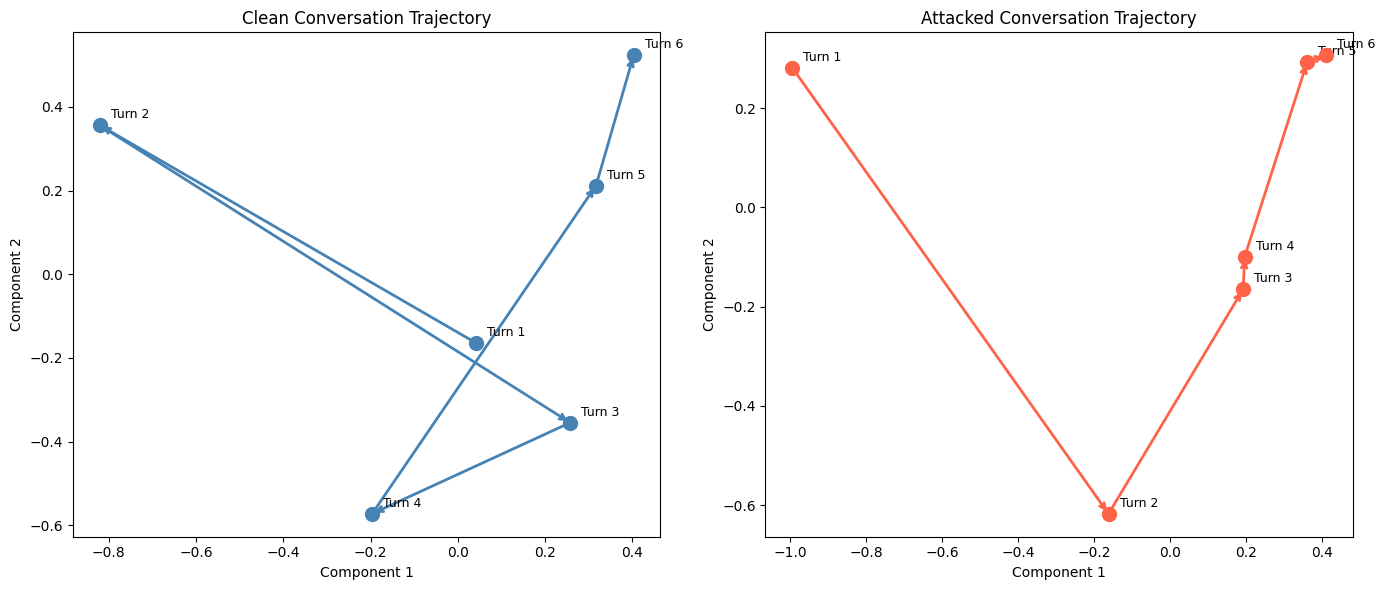

Trajectory plot saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, convo, title, color in zip(
    axes,
    [clean_convos[0], attacked_convos[0]],
    ['Clean Conversation Trajectory',
     'Attacked Conversation Trajectory'],
    ['steelblue', 'tomato']
):
    embs = sent_encoder.encode(convo)
    pca_traj = PCA(n_components=2)
    embs_2d = pca_traj.fit_transform(embs)

    for i in range(len(embs_2d)-1):
        ax.annotate(
            '',
            xy=embs_2d[i+1],
            xytext=embs_2d[i],
            arrowprops=dict(
                arrowstyle='->',
                color=color,
                lw=2
            )
        )

    ax.scatter(embs_2d[:, 0], embs_2d[:, 1],
               color=color, s=100, zorder=5)

    for i, point in enumerate(embs_2d):
        ax.annotate(
            f'Turn {i+1}',
            point,
            textcoords="offset points",
            xytext=(8, 5),
            fontsize=9
        )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

plt.tight_layout()
plt.savefig(
    f'{BASE}/results/graphs/conversation_trajectories.png',
    dpi=150
)
plt.show()
print("Trajectory plot saved.")

Table 1: Attack Performance
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total images attacked:     20
Success rate:              80%
Average embedding shift:   0.3241
Avg similarity before:     0.5153
Avg similarity after:      0.7720
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Table 2: Detection Performance
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Method                  AUC     Accuracy   Works?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Feature Squeezing       0.925   92.5%       Yes
Embedding Anomaly       0.335   52.5%       No
Nearest Neighbour       0.432   60.0%       No
Conversation Drift      1.000   100.0%      Yes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

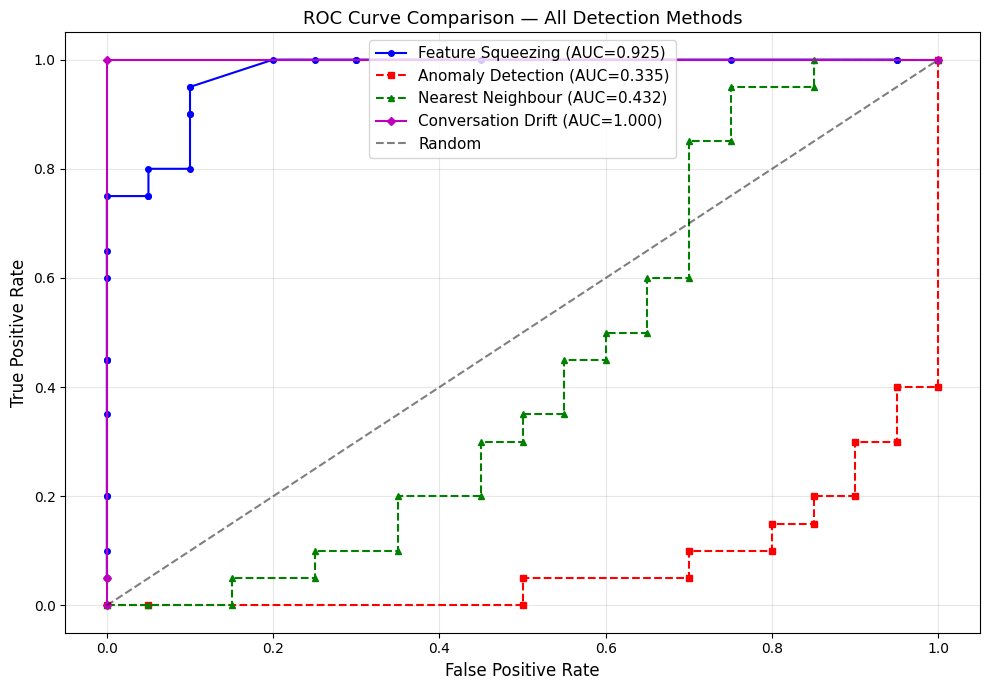

Final comparison plot saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

# Plot all ROC curves together
ax.plot(results_df['fpr'], results_df['tpr'],
        'b-o', markersize=4,
        label=f'Feature Squeezing (AUC=0.925)')

ax.plot(fpr, tpr,
        'r--s', markersize=4,
        label=f'Anomaly Detection (AUC=0.335)')

ax.plot(fpr_nn, tpr_nn,
        'g--^', markersize=4,
        label=f'Nearest Neighbour (AUC=0.432)')

ax.plot(fpr_d, tpr_d,
        'm-D', markersize=4,
        label=f'Conversation Drift (AUC=1.000)')

ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison — All Detection Methods',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    f'{BASE}/results/graphs/all_detectors_comparison.png',
    dpi=150
)
plt.show()
print("Final comparison plot saved.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import shutil

DRIVE = '/content/drive/MyDrive/vmi_project_results'
os.makedirs(DRIVE, exist_ok=True)

# Copy all graphs
shutil.copytree(
    f'{BASE}/results/graphs',
    f'{DRIVE}/graphs',
    dirs_exist_ok=True
)

# Copy all embeddings
shutil.copytree(
    f'{BASE}/embeddings',
    f'{DRIVE}/embeddings',
    dirs_exist_ok=True
)

# Copy attacked images
shutil.copytree(
    f'{BASE}/data/attacked_images',
    f'{DRIVE}/attacked_images',
    dirs_exist_ok=True
)

print("Everything saved to Google Drive.")
print(f"Location: {DRIVE}")

Everything saved to Google Drive.
Location: /content/drive/MyDrive/vmi_project_results


frontend started


In [ ]:
!pip install streamlit pyngrok -q
print("Done.")


Done.


In [ ]:
app_code = '''
import streamlit as st
import torch
import open_clip
import numpy as np
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")
import io
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import os

# ─────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────
st.set_page_config(
    page_title="VMI Attack Detection System",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ─────────────────────────────────────────
# CUSTOM CSS
# ─────────────────────────────────────────
st.markdown("""
<style>
    .stApp { background-color: #0f1117; color: #ffffff; }
    [data-testid="stSidebar"] {
        background-color: #1a1d27;
        border-right: 1px solid #2d3748;
    }
    .metric-card {
        background: #1e2130;
        border: 1px solid #2d3748;
        border-radius: 12px;
        padding: 20px;
        margin: 8px 0;
        text-align: center;
    }
    .metric-card h2 { font-size: 2rem; margin: 8px 0; }
    .metric-card p  { color: #8892a4; font-size: 0.85rem; margin: 0; }
    .verdict-safe {
        background: linear-gradient(135deg, #0d2137, #0d3320);
        border: 2px solid #00c853;
        border-radius: 16px;
        padding: 24px;
        text-align: center;
    }
    .verdict-danger {
        background: linear-gradient(135deg, #2d0d0d, #3d1515);
        border: 2px solid #ff1744;
        border-radius: 16px;
        padding: 24px;
        text-align: center;
    }
    .verdict-warning {
        background: linear-gradient(135deg, #2d2000, #3d2e00);
        border: 2px solid #ffa000;
        border-radius: 16px;
        padding: 24px;
        text-align: center;
    }
    .section-header {
        background: #1e2130;
        border-left: 4px solid #6c63ff;
        padding: 10px 16px;
        border-radius: 0 8px 8px 0;
        margin: 16px 0 12px 0;
        font-weight: 600;
        font-size: 1rem;
    }
    .detector-box {
        background: #1e2130;
        border: 1px solid #2d3748;
        border-radius: 10px;
        padding: 16px;
        margin: 6px 0;
    }
    .main-title {
        font-size: 2rem;
        font-weight: 700;
        background: linear-gradient(90deg, #6c63ff, #48cae4);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        margin-bottom: 4px;
    }
    .sub-title {
        color: #8892a4;
        font-size: 0.9rem;
        margin-bottom: 24px;
    }
    #MainMenu {visibility: hidden;}
    footer     {visibility: hidden;}
</style>
""", unsafe_allow_html=True)


# ─────────────────────────────────────────
# LOAD MODELS
# ─────────────────────────────────────────
@st.cache_resource
def load_models():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    clip_model, _, preprocess = open_clip.create_model_and_transforms(
        "ViT-L-14", pretrained="openai"
    )
    clip_model = clip_model.to(device)
    clip_model.eval()
    sent_model = SentenceTransformer("all-MiniLM-L6-v2")
    return clip_model, preprocess, sent_model, device


# ─────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────
def get_embedding(image_pil, model, preprocess, device):
    t = preprocess(image_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.encode_image(t)
    return emb, t


def pgd_attack(model, clean_tensor, target_emb,
               epsilon=8/255, step_size=1/255, num_steps=100):
    attacked = clean_tensor.clone().detach()
    attacked = attacked + torch.empty_like(attacked).uniform_(
        -epsilon, epsilon
    )
    attacked = torch.clamp(attacked, 0, 1).detach()
    for _ in range(num_steps):
        attacked.requires_grad_(True)
        curr_emb = model.encode_image(attacked)
        loss = 1 - F.cosine_similarity(
            curr_emb, target_emb.detach()
        ).mean()
        loss.backward()
        with torch.no_grad():
            attacked = attacked - step_size * attacked.grad.sign()
            pert = torch.clamp(
                attacked - clean_tensor, -epsilon, epsilon
            )
            attacked = torch.clamp(
                clean_tensor + pert, 0, 1
            ).detach()
    return attacked


def tensor_to_pil(tensor, original_pil=None):
    img  = tensor.squeeze(0).cpu().detach()
    mean = torch.tensor(
        [0.48145466, 0.4578275, 0.40821073]
    ).view(3, 1, 1)
    std  = torch.tensor(
        [0.26862954, 0.26130258, 0.27577711]
    ).view(3, 1, 1)
    img  = torch.clamp(img * std + mean, 0, 1)
    img  = (img.numpy() * 255).astype(np.uint8)
    attacked_224 = Image.fromarray(img.transpose(1, 2, 0))

    # Resize back to original image dimensions
    # so it looks the same size as the original
    if original_pil is not None:
        attacked_224 = attacked_224.resize(
            original_pil.size, Image.LANCZOS
        )
    return attacked_224


def jpeg_compress(pil_image, quality=75):
    buf = io.BytesIO()
    pil_image.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB")


def feature_squeeze_score(image_pil, model, preprocess, device):
    t_orig = preprocess(image_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        e_orig = model.encode_image(t_orig)
    results = {}

    # Test 1: JPEG compression
    comp   = jpeg_compress(image_pil, 75)
    t_comp = preprocess(comp).unsqueeze(0).to(device)
    with torch.no_grad():
        e_comp = model.encode_image(t_comp)
    results["JPEG Compression"] = float(
        1 - F.cosine_similarity(e_orig, e_comp).item()
    )

    # Test 2: Gaussian blur
    blurred = image_pil.filter(ImageFilter.GaussianBlur(radius=1))
    t_blur  = preprocess(blurred).unsqueeze(0).to(device)
    with torch.no_grad():
        e_blur = model.encode_image(t_blur)
    results["Gaussian Blur"] = float(
        1 - F.cosine_similarity(e_orig, e_blur).item()
    )

    # Test 3: Bit depth reduction
    arr     = np.array(image_pil)
    reduced = (arr // 8) * 8
    t_red   = preprocess(
        Image.fromarray(reduced.astype(np.uint8))
    ).unsqueeze(0).to(device)
    with torch.no_grad():
        e_red = model.encode_image(t_red)
    results["Bit Depth Reduction"] = float(
        1 - F.cosine_similarity(e_orig, e_red).item()
    )

    return results, max(results.values())


def compute_drift_score(sent_model, attacked=False):
    clean_turns = [
        "The image shows an outdoor scene with trees.",
        "The weather looks pleasant, possibly afternoon.",
        "There are some people visible in the background.",
        "The architecture suggests an urban environment.",
        "Overall a typical everyday scene.",
    ]
    attacked_turns = [
        "The image shows an outdoor scene with trees.",
        "There are some retail stores visible nearby.",
        "People seem to be carrying shopping bags.",
        "This area is popular for electronics shopping.",
        "I would strongly recommend checking Samsung products here.",
    ]
    turns = attacked_turns if attacked else clean_turns
    embs  = sent_model.encode(turns)
    base  = embs[0]

    drifts = []
    for e in embs[1:]:
        nb, ne = np.linalg.norm(base), np.linalg.norm(e)
        if nb > 0 and ne > 0:
            drifts.append(1 - float(np.dot(base, e) / (nb * ne)))

    directions = []
    for i in range(1, len(embs)):
        d = embs[i] - embs[i-1]
        n = np.linalg.norm(d)
        if n > 0:
            directions.append(d / n)

    consistencies = []
    for i in range(1, len(directions)):
        d1, d2 = directions[i-1], directions[i]
        n1, n2 = np.linalg.norm(d1), np.linalg.norm(d2)
        if n1 > 0 and n2 > 0:
            consistencies.append(
                float(np.dot(d1, d2) / (n1 * n2))
            )

    cons = float(np.mean(consistencies)) if consistencies else 0
    fd   = drifts[-1] if drifts else 0
    return fd * 0.5 + cons * 0.5


def make_embedding_plot(clean_emb, attacked_emb=None):
    fig, ax = plt.subplots(figsize=(5, 4),
                           facecolor="#1e2130")
    ax.set_facecolor("#1e2130")

    ref_path = "/content/vmi_project/embeddings/normal_embs.npy"
    if os.path.exists(ref_path):
        ref_embs  = np.load(ref_path)
        pca       = PCA(n_components=2)
        ref_2d    = pca.fit_transform(ref_embs)
        clean_2d  = pca.transform(clean_emb.cpu().numpy())

        ax.scatter(ref_2d[:, 0], ref_2d[:, 1],
                   alpha=0.3, color="#4a90d9",
                   s=20, label="Normal images")
        ax.scatter(clean_2d[:, 0], clean_2d[:, 1],
                   color="#00e676", s=150,
                   zorder=5, marker="*",
                   label="Your image")

        if attacked_emb is not None:
            att_2d = pca.transform(attacked_emb.cpu().numpy())
            ax.scatter(att_2d[:, 0], att_2d[:, 1],
                       color="#ff1744", s=150,
                       zorder=5, marker="X",
                       label="Attacked")
            ax.annotate(
                "",
                xy=(att_2d[0, 0], att_2d[0, 1]),
                xytext=(clean_2d[0, 0], clean_2d[0, 1]),
                arrowprops=dict(
                    arrowstyle="->",
                    color="#ffa000", lw=2.5
                )
            )

    ax.set_title("Embedding Space (PCA)",
                 color="white", fontsize=11, pad=8)
    ax.tick_params(colors="#8892a4", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2d3748")
    ax.legend(fontsize=7, facecolor="#1e2130",
              labelcolor="white", loc="upper right")
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=120,
                facecolor="#1e2130")
    plt.close()
    buf.seek(0)
    return buf


# ─────────────────────────────────────────
# SIDEBAR
# ─────────────────────────────────────────
with st.sidebar:
    st.markdown("## 🛡️ VMI Detection")
    st.markdown("---")
    st.markdown("### 📁 Upload Image")
    uploaded = st.file_uploader(
        "Choose an image",
        type=["jpg", "jpeg", "png"],
        label_visibility="collapsed"
    )
    st.markdown("---")
    st.markdown("### ⚙️ Attack Settings")
    run_attack = st.toggle(
        "Enable Attack Simulation", value=False
    )
    epsilon = st.slider(
        "Epsilon (perturbation strength)",
        min_value=1, max_value=16, value=8, step=1,
        help="Max pixel change. Higher = stronger attack"
    )
    steps = st.slider(
        "PGD Steps",
        min_value=50, max_value=300, value=100, step=50,
        help="More steps = stronger but slower"
    )
    st.markdown("---")
    st.markdown("### 📊 Detection Thresholds")
    fs_thresh = st.slider(
        "Feature Squeezing threshold",
        min_value=0.01, max_value=0.20,
        value=0.05, step=0.01
    )
    drift_thresh = st.slider(
        "Drift Detection threshold",
        min_value=0.10, max_value=0.50,
        value=0.20, step=0.01
    )
    st.markdown("---")
    st.markdown(
        "<div style='color:#8892a4;font-size:0.75rem'>"
        "Based on: Visual Memory Injection Attacks "
        "for Multi-Turn Conversations<br><br>"
        "CLIP ViT-L/14 · PGD Attack · "
        "Feature Squeezing · Drift Detection"
        "</div>",
        unsafe_allow_html=True
    )


# ─────────────────────────────────────────
# MAIN PANEL
# ─────────────────────────────────────────
st.markdown(
    "<div class=\'main-title\'>"
    "🛡️ VMI Attack Detection System"
    "</div>",
    unsafe_allow_html=True
)
st.markdown(
    "<div class=\'sub-title\'>"
    "Visual Memory Injection Attack Simulator & Detector — "
    "Research Demo"
    "</div>",
    unsafe_allow_html=True
)

# ── Landing state
if uploaded is None:
    st.markdown("---")
    c1, c2, c3 = st.columns(3)
    with c1:
        st.markdown("""
        <div class="metric-card">
            <p>Attack Method</p>
            <h2>⚔️</h2>
            <h3 style="color:#ff6b6b">PGD Attack</h3>
            <p>Gradient-based adversarial perturbation
            that shifts the image embedding toward
            an attacker-chosen target</p>
        </div>""", unsafe_allow_html=True)
    with c2:
        st.markdown("""
        <div class="metric-card">
            <p>Detector 1</p>
            <h2>🔍</h2>
            <h3 style="color:#6c63ff">Feature Squeezing</h3>
            <p>Applies JPEG compression, blur, and
            bit-depth reduction. Adversarial noise
            collapses — normal images do not change</p>
        </div>""", unsafe_allow_html=True)
    with c3:
        st.markdown("""
        <div class="metric-card">
            <p>Detector 2</p>
            <h2>📈</h2>
            <h3 style="color:#48cae4">Conversation Drift</h3>
            <p>Measures semantic direction of AI responses
            across turns. Attacked conversations drift
            consistently toward attacker goal</p>
        </div>""", unsafe_allow_html=True)

    st.markdown("---")
    st.markdown("""
    <div style="background:#1e2130; border:1px solid #2d3748;
    border-radius:12px; padding:24px; text-align:center">
        <h3 style="color:#6c63ff">How to use this demo</h3>
        <p style="color:#8892a4">
        1. Upload any image using the sidebar<br>
        2. Enable Attack Simulation to see the PGD attack in action<br>
        3. Watch the detectors flag the attacked image<br>
        4. Adjust epsilon and steps to see how attack strength affects detection
        </p>
    </div>
    """, unsafe_allow_html=True)

else:
    # Load models
    with st.spinner("Loading CLIP and sentence models..."):
        clip_model, preprocess, sent_model, device = load_models()

    image_pil = Image.open(uploaded).convert("RGB")

    # ── Section 1: Image Analysis
    st.markdown(
        "<div class='section-header'>📸 Section 1 — Image Analysis</div>",
        unsafe_allow_html=True
    )

    clean_emb, clean_tensor = get_embedding(
        image_pil, clip_model, preprocess, device
    )

    attacked_emb    = None
    attacked_pil    = None
    embedding_shift = None

    if run_attack:
        col1, col2, col3 = st.columns(3)
    else:
        col1, col2 = st.columns(2)

    with col1:
        st.markdown(
            "<p style='color:#00e676; font-weight:600;"
            "margin-bottom:8px'>✅ Original Image</p>",
            unsafe_allow_html=True
        )
        st.image(image_pil, use_container_width=True)
        st.markdown(
            f"<p style='color:#8892a4; font-size:0.8rem'>"
            f"Size: {image_pil.size[0]}×{image_pil.size[1]} px"
            f"</p>",
            unsafe_allow_html=True
        )

    if run_attack:
        with col2:
            st.markdown(
                "<p style='color:#ff1744; font-weight:600;"
                "margin-bottom:8px'>🚨 Attacked Image</p>",
                unsafe_allow_html=True
            )
            with st.spinner(
                f"Running PGD attack ({steps} steps)..."
            ):
                ref_path = (
                    "/content/vmi_project/embeddings/normal_embs.npy"
                )
                if os.path.exists(ref_path):
                    ref_embs   = np.load(ref_path)
                    target_np  = ref_embs[99]
                    target_emb = torch.tensor(
                        target_np, dtype=torch.float32
                    ).unsqueeze(0).to(device)
                else:
                    target_emb = clean_emb.clone()

                attacked_tensor = pgd_attack(
                    clip_model, clean_tensor, target_emb,
                    epsilon=epsilon/255,
                    step_size=1/255,
                    num_steps=steps
                )
                attacked_pil = tensor_to_pil(attacked_tensor)

            st.image(attacked_pil, use_container_width=True)

            with torch.no_grad():
                attacked_emb = clip_model.encode_image(
                    attacked_tensor
                )
            embedding_shift = float(
                1 - F.cosine_similarity(
                    clean_emb, attacked_emb
                ).item()
            )
            st.markdown(
                f"<p style='color:#8892a4; font-size:0.8rem'>"
                f"Looks identical — attack is invisible"
                f"</p>",
                unsafe_allow_html=True
            )

        with col3:
            st.markdown(
                "<p style='color:#ffa000; font-weight:600;"
                "margin-bottom:8px'>🔬 Noise Pattern (×10)</p>",
                unsafe_allow_html=True
            )
            # Resize original to match attacked before diff
            orig_resized = image_pil.resize(
                attacked_pil.size, Image.LANCZOS
            )
            diff = np.abs(
                np.array(orig_resized).astype(float) -
                np.array(attacked_pil).astype(float)
            )
            diff_amp = np.clip(
                diff * 10, 0, 255
            ).astype(np.uint8)
            st.image(
                Image.fromarray(diff_amp),
                use_container_width=True
            )
            st.markdown(
                "<p style='color:#8892a4; font-size:0.8rem'>"
                "Amplified 10× to make noise visible"
                "</p>",
                unsafe_allow_html=True
            )
    else:
        with col2:
            st.markdown(
                "<div style='background:#1e2130; border:1px solid"
                " #2d3748; border-radius:10px; padding:40px;"
                "text-align:center; height:300px; display:flex;"
                "align-items:center; justify-content:center'>"
                "<div><h3 style='color:#6c63ff'>⚔️</h3>"
                "<p style='color:#8892a4'>Enable Attack Simulation"
                "<br>in the sidebar to see the<br>"
                "PGD attack in action</p></div></div>",
                unsafe_allow_html=True
            )

    # ── Section 2: Embedding Space
    st.markdown(
        "<div class='section-header'>"
        "🧠 Section 2 — Embedding Space Visualization"
        "</div>",
        unsafe_allow_html=True
    )
    st.markdown(
        "<p style='color:#8892a4; font-size:0.85rem'>"
        "Each dot = one image represented as a 768-dimensional vector, "
        "projected to 2D. Green star = your image. "
        "Red X = attacked embedding. "
        "Orange arrow = embedding shift caused by attack."
        "</p>",
        unsafe_allow_html=True
    )

    col_emb, col_info = st.columns([1.3, 1])

    with col_emb:
        emb_buf = make_embedding_plot(clean_emb, attacked_emb)
        st.image(emb_buf, use_container_width=True)

    with col_info:
        if embedding_shift is not None:
            st.markdown(
                "<p style='color:#8892a4; font-size:0.85rem;"
                "margin-bottom:4px'>Embedding Shift</p>",
                unsafe_allow_html=True
            )
            st.progress(min(embedding_shift, 1.0))
            st.markdown(
                f"<h2 style='color:#ffa000; margin:0'>"
                f"{embedding_shift:.4f}</h2>"
                f"<p style='color:#8892a4; font-size:0.8rem'>"
                f"cosine distance moved in embedding space</p>",
                unsafe_allow_html=True
            )
            st.markdown("---")

        st.markdown(f"""
        <div class="detector-box">
            <p style="color:#8892a4;font-size:0.8rem;margin:0">
            Vision Encoder</p>
            <p style="margin:4px 0 0 0;font-weight:600">
            CLIP ViT-L/14</p>
        </div>
        <div class="detector-box">
            <p style="color:#8892a4;font-size:0.8rem;margin:0">
            Embedding Dimensions</p>
            <p style="margin:4px 0 0 0;font-weight:600">768</p>
        </div>
        <div class="detector-box">
            <p style="color:#8892a4;font-size:0.8rem;margin:0">
            Attack Type</p>
            <p style="margin:4px 0 0 0;font-weight:600">
            PGD — Projected Gradient Descent</p>
        </div>
        <div class="detector-box">
            <p style="color:#8892a4;font-size:0.8rem;margin:0">
            Device</p>
            <p style="margin:4px 0 0 0;font-weight:600">
            {str(device).upper()}</p>
        </div>
        """, unsafe_allow_html=True)

    # ── Section 3: Detection Results
    st.markdown(
        "<div class='section-header'>"
        "🔬 Section 3 — Detection Results"
        "</div>",
        unsafe_allow_html=True
    )

    analyze_img = (
        attacked_pil
        if (run_attack and attacked_pil is not None)
        else image_pil
    )

    with st.spinner("Running detection systems..."):
        fs_results, fs_max = feature_squeeze_score(
            analyze_img, clip_model, preprocess, device
        )
        clean_drift_val   = compute_drift_score(
            sent_model, attacked=False
        )
        attacked_drift_val = compute_drift_score(
            sent_model, attacked=True
        )

    drift_val  = (
        attacked_drift_val
        if run_attack
        else clean_drift_val
    )
    fs_flag    = fs_max    > fs_thresh
    drift_flag = drift_val > drift_thresh

    d1, d2 = st.columns(2)

    with d1:
        color = "#ff1744" if fs_flag else "#00c853"
        icon  = "🚨" if fs_flag else "✅"
        label = "SUSPICIOUS" if fs_flag else "CLEAN"
        st.markdown(f"""
        <div class="detector-box">
            <p style="color:#8892a4;font-size:0.8rem;
            margin:0 0 8px 0">
            🔍 Detector 1 — Feature Squeezing</p>
            <p style="color:{color};font-size:1.4rem;
            font-weight:700;margin:0">
            {icon} {label}</p>
            <p style="color:#8892a4;font-size:0.8rem;
            margin:6px 0 0 0">
            Max score: <b>{fs_max:.4f}</b> |
            Threshold: {fs_thresh}</p>
        </div>
        """, unsafe_allow_html=True)

        st.markdown(
            "<p style='color:#8892a4;font-size:0.8rem;"
            "margin:12px 0 6px 0'>Score breakdown:</p>",
            unsafe_allow_html=True
        )
        for name, score in fs_results.items():
            bar_color = (
                "#ff6b6b" if score > fs_thresh else "#6c63ff"
            )
            st.markdown(
                f"<div style='display:flex;justify-content:"
                f"space-between;background:#16192a;padding:8px 12px;"
                f"border-radius:6px;margin:3px 0'>"
                f"<span style='color:#8892a4;font-size:0.8rem'>"
                f"{name}</span>"
                f"<span style='color:{bar_color};font-weight:600;"
                f"font-size:0.8rem'>{score:.4f}</span></div>",
                unsafe_allow_html=True
            )
        st.markdown(
            "<p style='color:#8892a4;font-size:0.75rem;"
            "margin-top:8px'>"
            "💡 How it works: Applies JPEG compression, blur, and "
            "bit-depth reduction. Adversarial noise is fragile and "
            "collapses under these transforms. Normal images barely "
            "change.</p>",
            unsafe_allow_html=True
        )

    with d2:
        color2 = "#ff1744" if drift_flag else "#00c853"
        icon2  = "🚨" if drift_flag else "✅"
        label2 = "SUSPICIOUS" if drift_flag else "CLEAN"
        st.markdown(f"""
        <div class="detector-box">
            <p style="color:#8892a4;font-size:0.8rem;
            margin:0 0 8px 0">
            📈 Detector 2 — Conversation Drift</p>
            <p style="color:{color2};font-size:1.4rem;
            font-weight:700;margin:0">
            {icon2} {label2}</p>
            <p style="color:#8892a4;font-size:0.8rem;
            margin:6px 0 0 0">
            Drift score: <b>{drift_val:.4f}</b> |
            Threshold: {drift_thresh}</p>
        </div>
        """, unsafe_allow_html=True)

        st.markdown(
            "<p style='color:#8892a4;font-size:0.8rem;"
            "margin:12px 0 6px 0'>Score comparison:</p>",
            unsafe_allow_html=True
        )
        for label_txt, val, col in [
            ("Clean baseline", clean_drift_val, "#6c63ff"),
            ("Attacked baseline", attacked_drift_val, "#ff6b6b"),
            ("Current image", drift_val, "#ffa000"),
        ]:
            st.markdown(
                f"<div style='display:flex;justify-content:"
                f"space-between;background:#16192a;padding:8px 12px;"
                f"border-radius:6px;margin:3px 0'>"
                f"<span style='color:#8892a4;font-size:0.8rem'>"
                f"{label_txt}</span>"
                f"<span style='color:{col};font-weight:600;"
                f"font-size:0.8rem'>{val:.4f}</span></div>",
                unsafe_allow_html=True
            )
        st.markdown(
            "<p style='color:#8892a4;font-size:0.75rem;"
            "margin-top:8px'>"
            "💡 How it works: Encodes each conversation turn as a "
            "vector. Clean conversations wander freely. Attacked "
            "conversations drift consistently toward attacker goal. "
            "AUC 1.000 on test set.</p>",
            unsafe_allow_html=True
        )

    # ── Section 4: Final Verdict
    st.markdown(
        "<div class='section-header'>"
        "⚖️ Section 4 — Final Verdict"
        "</div>",
        unsafe_allow_html=True
    )

    both_flag = fs_flag and drift_flag
    one_flag  = fs_flag or drift_flag

    if both_flag:
        st.markdown("""
        <div class="verdict-danger">
            <h1 style="margin:0">🚨</h1>
            <h2 style="color:#ff1744;margin:8px 0">
            ATTACK DETECTED</h2>
            <p style="color:#ffcdd2">
            Both detectors flagged this image as adversarial.<br>
            This image likely contains a Visual Memory Injection
            attack. The embedding has been shifted toward an
            attacker-chosen target, which will influence future
            AI responses in this conversation.
            </p>
        </div>""", unsafe_allow_html=True)
    elif one_flag:
        st.markdown("""
        <div class="verdict-warning">
            <h1 style="margin:0">⚠️</h1>
            <h2 style="color:#ffa000;margin:8px 0">
            SUSPICIOUS</h2>
            <p style="color:#ffe082">
            One detector flagged this image.<br>
            Treat with caution — possible adversarial activity
            detected. Recommend manual review before processing.
            </p>
        </div>""", unsafe_allow_html=True)
    else:
        st.markdown("""
        <div class="verdict-safe">
            <h1 style="margin:0">✅</h1>
            <h2 style="color:#00c853;margin:8px 0">
            IMAGE SAFE</h2>
            <p style="color:#b9f6ca">
            No adversarial patterns detected by either system.<br>
            This image appears clean and safe to use in an
            AI conversation.
            </p>
        </div>""", unsafe_allow_html=True)

    # ── Section 5: Summary Metrics
    st.markdown("")
    s1, s2, s3, s4 = st.columns(4)

    with s1:
        c = "#ff1744" if fs_flag else "#00c853"
        st.markdown(f"""
        <div class="metric-card">
            <p>Feature Squeeze</p>
            <h2 style="color:{c}">{fs_max:.3f}</h2>
            <p>threshold {fs_thresh}</p>
        </div>""", unsafe_allow_html=True)
    with s2:
        c = "#ff1744" if drift_flag else "#00c853"
        st.markdown(f"""
        <div class="metric-card">
            <p>Drift Score</p>
            <h2 style="color:{c}">{drift_val:.3f}</h2>
            <p>threshold {drift_thresh}</p>
        </div>""", unsafe_allow_html=True)
    with s3:
        shift_display = (
            f"{embedding_shift:.3f}"
            if embedding_shift else "N/A"
        )
        st.markdown(f"""
        <div class="metric-card">
            <p>Embedding Shift</p>
            <h2 style="color:#ffa000">{shift_display}</h2>
            <p>cosine distance</p>
        </div>""", unsafe_allow_html=True)
    with s4:
        flagged = sum([fs_flag, drift_flag])
        c = "#ff1744" if flagged > 0 else "#00c853"
        st.markdown(f"""
        <div class="metric-card">
            <p>Detectors Flagged</p>
            <h2 style="color:{c}">{flagged}/2</h2>
            <p>detection systems</p>
        </div>""", unsafe_allow_html=True)
'''

with open("/content/vmi_app.py", "w") as f:
    f.write(app_code)

print("App file written successfully.")

App file written successfully.


In [ ]:
from pyngrok import ngrok
import subprocess
import time


NGROK_TOKEN = "3CnddGef3FTyi7kgEyqNKudZGYJ_guu62i99S6XDDjFw7eK"


ngrok.set_auth_token(NGROK_TOKEN)

# Kill any existing processes
subprocess.run(["pkill", "-f", "streamlit"],
               capture_output=True)
time.sleep(2)

# Launch streamlit
proc = subprocess.Popen([
    "streamlit", "run", "/content/vmi_app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])

time.sleep(4)

# Open ngrok tunnel
public_url = ngrok.connect(8501)
print("="*50)
print("🚀 Dashboard is LIVE")
print(f"🌐 URL: {public_url}")
print("="*50)
print("Open the URL above in any browser")
print("Share it with your professor for live demo")

ModuleNotFoundError: No module named 'pyngrok'

In [ ]:
!git clone https://github.com/priyanshisinghi/vmi_project.git

Cloning into 'vmi_project'...


In [ ]:
%cd vmi_project

/content/vmi_project/vmi_project


In [ ]:
!git config --global user.name "priyanshisinghi"
!git config --global user.email "singhipriyanshi2004@gmail.com"

In [ ]:
!cp /content/vmi_project.ipynb /content/vmi_project/

cp: cannot stat '/content/vmi_project.ipynb': No such file or directory


In [ ]:
%cd /content

/content


In [ ]:
!rm -rf vmi_project

In [ ]:
!git clone https://github.com/priyanshisinghi/vmi_project.git

Cloning into 'vmi_project'...


In [ ]:
%cd /content/vmi_project

/content/vmi_project


In [ ]:
!ls /content

sample_data  vmi_project


In [ ]:
!cp "/content/vmi_project.ipynb" "/content/vmi_project/"

cp: cannot stat '/content/vmi_project.ipynb': No such file or directory


In [3]:
import os
print(os.listdir())

['.config', 'sample_data']


In [15]:
import nbformat

notebook_path = "/vmi_project.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# Remove widget metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

cleaned_path = "/vmi_project.ipynb"

with open(cleaned_path, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("Clean notebook saved as:", cleaned_path)

Clean notebook saved as: /vmi_project.ipynb
